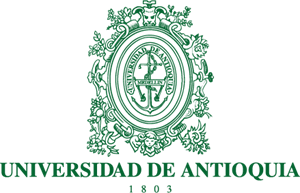

##**Universidad de Antioquia**

**Especialización en Analítica y Ciencia de Datos**

**Erik Estiven Arias Paniagua CC 1036608270**

**Anderson Guisao Padrón CC 1036622768**

##**Librerias**

In [66]:
import math
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (mean_absolute_error,
                             r2_score,
                             root_mean_squared_error)
#from sktime.performance_metrics.forecasting import mean_absolute_scaled_error

#Factor de Inflación de la Varianza VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor



# Función para graficar atributos en barras, pair plot o box-plot
def multiple_plot(ncols, data, columns, target_var, plot_type, title, rot):
    '''
    Returns the figure build from input parameters.

        Parameters:
            ncols       [integer]    Number of columns for subplots.
            data        [dataframe]  Features dataframe.
            columns     [list]       List of names of featutes in dataframe to plot.
            target_var  [string]     Name of column of target variable or feature.
            plot_type   [string]     Name of graphic. [countplot, boxplt or scatterplot]
            title       [string]     Title for figure
            rot         [integer]    Rotation angle for x axis labels
        Returns:
            Plot of figure

    Ejemplos:
        multiple_plot(1, d , None, 'bad_credit', 'countplot', 'Frecuencia de instancias para la variable bad_credit',0)
        multiple_plot(1, d , 'purpose', 'age_yrs', 'boxplot', 'Distribución de la variable próposito vs la edad',90)
        multiple_plot(1, d , numCols, None, 'scatterplot', 'Relación entre las variables numéricas',30)
        multiple_plot(3, d , catCols, None, 'countplot', 'Frecuencia de instancias para variables categóricas',30)
        multiple_plot(3, d , catCols, 'age_yrs', 'boxplot', 'Distribución de la variables categóticas vs. la edad',30)
    '''


    # Paletas de colores y colores de las gráficas
    paletas = ['nipy_spectral','hsv','jet_r','Paired','Set2','Dark2','tab10','husl','mako']
    color = ['steelblue','forestgreen', 'amber']


    # Parámetros iniciales
    title_dist = 1.1  # Ajusta la distancia vertical del título en el gráfico
    x = -1            # Ubicación en el eje x del gráfico
    y =  0            # Ubicación en el eje y del gráfico
    nrows = 1         # Número inicial de filas


    # Ajustar el número de filas según el tipo de gráfico y la cantidad de columnas
    if isinstance(columns, list):
        nrows = math.ceil(len(columns) / ncols)

    # Crear el gráfico según el tipo especificado
    if ((nrows <= 1 and ncols <= 1) or plot_type == 'scatterplot'):

        # Countplot
        if plot_type == 'countplot':
            # Configurar el gráfico countplot
            fig, axes = plt.subplots(1, 1, figsize=(6, 4))
            ax_cond = axes
            sns.countplot(data=data,
                          x=target_var,
                          ax=axes,
                          palette=paletas[0],
                          zorder=1,
                          order=data[target_var].value_counts().index,
                          alpha=0.8
                          )
            # Personalizar el eje x
            ax_cond.set_xticklabels(ax_cond.get_xticklabels(), rotation=rot)
            # Configurar título
            ax_cond.set_title(title, fontsize=14, fontweight="bold", y=title_dist)

        # Boxplot
        elif plot_type == 'boxplot':
            # Configurar el gráfico boxplot
            fig, axes = plt.subplots(1, 1, figsize=(6, 4))
            ax_cond = axes
            sns.boxplot(data=data,
                        x=columns,
                        y=target_var,
                        ax=axes,
                        palette=paletas[0],
                        zorder=1
                        )
            # Personalizar el eje x
            ax_cond.set_xticklabels(ax_cond.get_xticklabels(), rotation=rot)
            # Configurar título
            ax_cond.set_title(title, fontsize=14, fontweight="bold", y=title_dist)


        # Scatterplot Matrix (Pairplot)
        elif plot_type == 'scatterplot':
            # Configurar el gráfico pairplot
            plot = sns.pairplot(data[columns],
                                palette=paletas[0],
                                diag_kws={'color': color[1]},
                                plot_kws={'color': color[0]},
                                diag_kind='kde'
                                )
            # Ajustar el tamaño del gráfico
            plot.fig.set_size_inches(12, 12)
            # Añadir un título al pairplot
            plot.fig.suptitle(title, fontsize=14, fontweight="bold")
            # Ajustar el diseño para evitar solapamientos
            plt.subplots_adjust(top=0.9)
            # Mostrar el gráfico
            plt.show()

    # Graficar más de un subplot
    else:
        # Crear subplots con el número especificado de filas y columnas
        fig, axes = plt.subplots(nrows, ncols, figsize=(15, (nrows * 3) + 1))

        for i, column in enumerate(columns):
            x = x + 1

            # Reiniciar x e incrementar y si x alcanza el número de columnas
            if x >= ncols:
                y = y + 1
                x = 0

            # Configurar el subplot actual
            if nrows == 1:
                ax_cond = axes[i]
                title_dist = 1.1
            else:
                ax_cond = axes[y, x]

            # Crear el gráfico según el tipo especificado
            if plot_type == 'countplot':
                # Countplot
                sns.countplot(data=data,
                              x=column,
                              ax=ax_cond,
                              palette=paletas[0],
                              zorder=1,
                              edgecolor='black',
                              linewidth=0.5,
                              order=data[column].value_counts().index
                              )

            elif plot_type == 'boxplot':
                # Boxplot
                sns.boxplot(data=data,
                            x=column,
                            y=target_var,
                            ax=ax_cond,
                            palette=paletas[0],
                            zorder=1
                            )

            # Añadir cuadrícula en el eje y
            ax_cond.grid(axis='y', zorder=0)
            # Personalizar el eje x
            ax_cond.set_xticklabels(ax_cond.get_xticklabels(), rotation=rot)
            # Configurar título del subplot
            ax_cond.set_title(column, fontsize=10)
            # Ajustar tamaño de las etiquetas
            ax_cond.tick_params(labelsize=8)
            # Limpiar etiquetas del eje x
            ax_cond.set_xlabel("")

        # Ajustar el diseño y el título general del conjunto de subplots
        fig.tight_layout()
        fig.suptitle(title, fontsize=14, fontweight="bold", y=title_dist - 0.15)
        plt.subplots_adjust(top=0.9)

        # Eliminar subplots sin datos si hay más de una fila
        if nrows > 1:
            for ax in axes.flat:
                if not bool(ax.has_data()):
                    fig.delaxes(ax)  # Eliminar si no hay datos en el subplot


# Funcion para imprimir la curva ROC
def plot_roc_curve(fpr, tpr):
    '''
    Funcion para imprimir la curva ROC
    '''
    plt.plot(fpr, tpr, color='orange', label='ROC')
    plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend()
    plt.show()

# Función para convertir una matriz de correlación de pandas en formato tidy
def tidy_corr_matrix(corr_mat):
    '''
    Función para convertir una matriz de correlación de pandas en formato tidy
    '''
    corr_mat = corr_mat.stack().reset_index()
    corr_mat.columns = ['variable_1','variable_2','r']
    corr_mat = corr_mat.loc[corr_mat['variable_1'] != corr_mat['variable_2'], :]
    corr_mat['abs_r'] = np.abs(corr_mat['r'])
    corr_mat = corr_mat.sort_values('abs_r', ascending=False)

    return(corr_mat)

#Función para calcular VIF (Variance Inflation Factor):


def checkVIF(X):
    '''
    Se Utiliza VIF para solucionar la multicolinealidad. VIF indica el grado de indecencia de esa variable.
    Los valores de los umbrales típicos que se suelen utilizar son entre 5 y 10, siendo más exigentes los valores más bajos.
    '''
    vif = pd.DataFrame()
    vif['Features'] = X.columns
    vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif['VIF'] = round(vif['VIF'], 2)
    vif = vif.sort_values(by = "VIF", ascending = False)
    return(vif)

def identificar_outliers(df, numCols):
    """
    Identifica los índices de los valores outliers en un DataFrame para una lista de variables numéricas.

    Parámetros:
    df (pd.DataFrame): El DataFrame que contiene los datos.
    numCols (list): Lista de nombres de las columnas numéricas a analizar.

    Retorna:
    list: Lista de índices de los valores outliers.
    """
    # Lista para almacenar los índices de los outliers
    outliers_indices = []

    for var in numCols:
        # Calcular el rango intercuartílico (IQR)
        Q1 = df[var].quantile(0.25)
        Q3 = df[var].quantile(0.75)
        IQR = Q3 - Q1

        # Definir los límites para identificar outliers
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Identificar los índices de los outliers
        outliers = df[(df[var] < lower_bound) | (df[var] > upper_bound)].index.tolist()

        # Agregar los índices a la lista de outliers
        outliers_indices.extend(outliers)

    return outliers_indices

def eval_model(model, X_train, y_train):
    """
    Permite evaluar el rendimiento de un modelo de regresión utilizando varias métricas.

    Parámetros:
    model (object): El modelo de regresión que se va a evaluar.
    X_train (array-like): Conjunto de características de entrenamiento.
    y_train (array-like): Valores reales de la variable objetivo para el conjunto de entrenamiento.

    Retorna:
    dict: Un diccionario que contiene las siguientes métricas de evaluación:
        - "mae": Error absoluto medio (Mean Absolute Error).
        - "rmse": Raíz del error cuadrático medio (Root Mean Squared Error).
        - "r2": Coeficiente de determinación (R²).
        - "mase": Error absoluto medio escalado (Mean Absolute Scaled Error).
    """
    y_pred = model.predict(X_train)

    metrics = {
        "mae": round(mean_absolute_error(y_train, y_pred), 5),
        "rmse": round(root_mean_squared_error(y_train, y_pred), 5),
        "r2": round(r2_score(y_train, y_pred), 5),
        "mase": round(mean_absolute_scaled_error(y_train, y_pred, y_train=y_train), 5)
    }

    return metrics

def plot_param_perf(x, y_data, title, x_label, y_label):
    """
    Grafica el rendimiento del modelo en función de un parámetro ajustado.

    Parámetros:
    x (iterable): Valores del parámetro ajustado.
    y_data (dict): Diccionario con las métricas de rendimiento para entrenamiento y prueba.
    title (str): Título del gráfico.
    x_label (str): Etiqueta del eje x.
    y_label (str): Etiqueta del eje y.
    """
    y_train = y_data["train"]
    y_test = y_data["test"]

    # Graficar las métricas de rendimiento para entrenamiento y prueba
    sns.lineplot(x=x, y=y_train, label="train")
    sns.lineplot(x=x, y=y_test, label="test")
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()


def search_param(base_model, X_train, y_train, X_test, y_test, base_params, search_param, search_range):
    """
    Busca el mejor valor para un parámetro específico del modelo, evaluando el rendimiento
    en términos de R² y MASE para los conjuntos de entrenamiento y prueba.

    Parámetros:
    base_model (object): El modelo base que se va a ajustar.
    X_train (array-like): Conjunto de características de entrenamiento.
    y_train (array-like): Valores reales de la variable objetivo para el conjunto de entrenamiento.
    X_test (array-like): Conjunto de características de prueba.
    y_test (array-like): Valores reales de la variable objetivo para el conjunto de prueba.
    base_params (dict): Parámetros base del modelo.
    search_param (str): El nombre del parámetro que se va a ajustar.
    search_range (iterable): Rango de valores para el parámetro que se va a buscar.

    Retorna:
    tuple: Dos diccionarios que contienen las métricas R² y MASE para los conjuntos de entrenamiento y prueba.
    """
    r2_train = []
    r2_test = []
    mase_train = []
    mase_test = []

    for param in search_range:

        # Actualizar los parámetros del modelo con el valor actual del parámetro en búsqueda
        model_params = base_params
        model_params[search_param] = param
        current_model = base_model.set_params(**model_params)

        print(f"Ajustando para {search_param}={param}")
        current_model.fit(X_train, y_train)

        # Guardar R² para entrenamiento y prueba
        r2_train.append(r2_score(y_train, current_model.predict(X_train)))
        r2_test.append(r2_score(y_test, current_model.predict(X_test)))

        # Guardar MASE para entrenamiento y prueba
        mase_train.append(
            mean_absolute_scaled_error(
                y_train, current_model.predict(X_train), y_train=y_train
            )
        )
        mase_test.append(
            mean_absolute_scaled_error(
                y_test, current_model.predict(X_test), y_train=y_test
            )
        )

    # Guardar métricas en diccionarios
    r2_scores = {"train": r2_train, "test": r2_test}
    mase_scores = {"train": mase_train, "test": mase_test}
    return r2_scores, mase_scores

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm


from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import plotly as py
import plotly.offline as pyoff
import plotly.graph_objs as go

import xgboost as xgb
from sklearn.model_selection import KFold, cross_val_score, train_test_split

import xgboost as xgb

In [68]:
# Tratamiento de datos
# ==============================================================================
import pandas as pd
import numpy as np


# Gestion de librerias
# ==============================================================================
from importlib import reload


# Matemáticas y estadísticas
# ==============================================================================
import math


# Preparación de datos
# ==============================================================================

from imblearn.over_sampling import RandomOverSampler
from sklearn.neighbors import LocalOutlierFactor


# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns


# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')


# Almacenar en caché los resultados de funciones en el disco
# ==============================================================================
import joblib


# Gestion de librerias
# ==============================================================================
from importlib import reload


# Preprocesado y modelado
# ==============================================================================


#Separar los datos entrenamiento y prueba
from sklearn.model_selection import train_test_split


#Escalar Variables
from sklearn.preprocessing import MinMaxScaler


#Evaluación del modelo
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve



#Creación de modelo
from sklearn.linear_model import LogisticRegression


# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns


# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

#Creación de modelo
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import MultinomialNB
import statsmodels.tsa.api as smt
import statsmodels.api as sm
import scipy.stats as stats
import plotly.express as px
import statsmodels.tsa.api as smt
import statsmodels.api as sm
from IPython.display import Image
from scipy.stats import randint
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import AdaBoostRegressor

# Preprocesado y modelado
# ==============================================================================
import math

#Separar los datos entrenamiento y prueba
from sklearn.model_selection import train_test_split


#Escalar Variables
from sklearn.preprocessing import MinMaxScaler


#Evaluación del modelo
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve


#Creación de modelo
from sklearn import svm


#configuracion de hiperparámetros
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns


# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

# Preprocesado y modelado
# ==============================================================================

#Separar los datos entrenamiento y prueba
from sklearn.model_selection import train_test_split


#Escalar Variables
from sklearn.preprocessing import MinMaxScaler


#Evaluación del modelo
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve


#Creación de modelo
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
#from sklearn.tree import export_graphviz
#from sklearn.tree import export_text


#configuracion de hiperparámetros
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns


# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')



#**Carga del Dataset**

In [69]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [70]:
df = pd.read_csv('/content/drive/MyDrive/Proyecto de Grado/Data_Analisis_Movilidad_U2Y.csv', encoding='latin1', sep=';', on_bad_lines='skip')


## **Visualización inicial del df**

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22947 entries, 0 to 22946
Data columns (total 45 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Dni_Aseg_Anonymized                      22947 non-null  object 
 1   Asegurado_Id_Anonymized                  22947 non-null  object 
 2   Poliza_Certificado_Id_Anonymized         22947 non-null  object 
 3   Numero_Poliza_Anonymized                 22947 non-null  object 
 4   Placa_Vehiculo_Anonymized                22947 non-null  object 
 5   Edad_Cliente                             22947 non-null  int64  
 6   segmento_edad                            22947 non-null  object 
 7   Sexo_Cd                                  22947 non-null  object 
 8   Estado_Civil_Desc                        22947 non-null  object 
 9   Ciudad_Cliente                           22947 non-null  object 
 10  Departamento_Cliente                     22947

In [72]:
# Crear resumen estadístico
resumen_estadistico = df.describe().T

# Agregar columnas de valores nulos y únicos
resumen_estadistico["nulls"] = df.isnull().sum()

resumen_estadistico["unique"] = df.nunique()

# Reordenar columnas
resumen_estadistico = resumen_estadistico[
    ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'nulls', 'unique']
]

styled_summary = (
    resumen_estadistico.style
    .format("{:.2f}", na_rep="NaN")  # Formato decimal
    .background_gradient(cmap='Blues', subset=['mean', 'std'])  # Color para medias y desviaciones
    .background_gradient(cmap='Reds', subset=['nulls'])         # Color para valores nulos
    .highlight_max(color='lightgreen', axis=0)                  # Resaltar máximos
    .highlight_min(color='lightcoral', axis=0)                  # Resaltar mínimos
    .set_caption("📊 Resumen Estadístico del DataFrame")
    .set_table_styles([{'selector': 'caption', 'props': [('font-size', '16px'), ('text-align', 'center')]}])
)


styled_summary


,count,mean,std,min,25%,50%,75%,max,nulls,unique
Edad_Cliente,22947.00,38.80,14.17,-1.00,29.00,36.00,47.00,98.00,0.00,91.00
Num_Total_Polizas_Cliente_CanalDD,22947.00,1.35,2.06,1.00,1.00,1.00,1.00,46.00,0.00,11.00
Modelo_Vehiculo,22947.00,2.02,0.01,1.96,2.02,2.02,2.02,2.03,0.00,54.00
Num_Total_Asistencias_Certificado,22947.00,0.57,1.62,0.00,0.00,0.00,0.00,30.00,0.00,27.00
Cliente_Tiene_Soat_Activo,22947.00,0.20,0.40,0.00,0.00,0.00,0.00,1.00,0.00,2.00
Cliente_Tiene_Hogar_Activo,22947.00,0.01,0.08,0.00,0.00,0.00,0.00,1.00,0.00,2.00
Cliente_Tiene_MasVida_Activo,22947.00,0.01,0.11,0.00,0.00,0.00,0.00,1.00,0.00,2.00
Cliente_Tiene_Salud_Activo,22947.00,0.07,0.26,0.00,0.00,0.00,0.00,1.00,0.00,2.00
Cliente_Tiene_Vida_Activo,22947.00,0.36,0.48,0.00,0.00,0.00,1.00,1.00,0.00,2.00


## **Limpieza de datos**

In [73]:
# Lista de columnas con separadores de miles
columnas_con_puntos = ['Rango_Ingresos_Cliente', 'Linea_Vehiculo_Calculada', 'Margen_Tecnico_Total_Certificado', 'Antiguedad_Cliente_En_CanalDD_Anios',
                       'Valor_Accesorios_Certificado', 'Vigencia_Total_Poliza_Meses',  'Ultima_Prima_Anualizada_Cert', 'Valor_Comercial_Vehiculo',
                       'Valor_Accesorios_Vehiculo_Sia', 'Valor_Accesorio_Especial_Veh', 'Prima_Total_Devengada_Certificado', 'Siniestros_Total_Incurridos_Certificado',
                       'Costo_Total_Asistencias_Certificado', 'Margen_Bruto_Total_Certificado', 'Rango_Ingresos_Cliente']

for col in columnas_con_puntos:
    # Paso 1: Eliminar puntos y cambiar coma por punto decimal
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
    )

    # Paso 2: Intentar convertir a numérico (si aplica)
    df[col] = pd.to_numeric(df[col], errors='ignore')  # usa 'coerce' si quieres forzar la conversión

In [74]:
#reemplazar "?" por 0 en Valor_Accesorios_Vehiculo_Sia', 'Valor_Accesorio_Especial_Veh

cols = ['Valor_Accesorios_Vehiculo_Sia', 'Valor_Accesorio_Especial_Veh']

# Reemplazar "?" por 0 y convertir a numérico
for col in cols:
    df[col] = df[col].replace('?', 0)
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [75]:
df["Edad_Cliente"] = pd.to_numeric(df["Edad_Cliente"], errors="coerce")

# Calcular la media solo con edades válidas (mayores o iguales a 18)
media_edad = df.loc[df["Edad_Cliente"] >= 18, "Edad_Cliente"].mean()

# Reemplazar edades menores a 18 y -1 por la media
df.loc[(df["Edad_Cliente"] < 18) | (df["Edad_Cliente"] == -1), "Edad_Cliente"] = media_edad


In [76]:
# Reemplazar "?" por NaN
df["segmento_edad"] = df["segmento_edad"].replace("?", np.nan)

# Calcular la moda (valor más frecuente)
moda_segmento = df["segmento_edad"].mode()[0]

# Reemplazar NaN (antes "?") con la moda
df["segmento_edad"] = df["segmento_edad"].fillna(moda_segmento)


In [77]:
# Eliminar filas donde Sexo_Cd sea igual a '-1'
df = df[~df["Sexo_Cd"].astype(str).str.strip().eq("-1")].copy()

In [78]:
# Columnas donde se debe eliminar 'Sin_Información'
columnas = ["Ciudad_Cliente", "Departamento_Cliente", "Sector_Economico_Cliente"]

# Eliminar filas que contengan 'Sin_Información' (con limpieza de espacios y mayúsculas)
for col in columnas:
    df = df[~df[col].astype(str).str.strip().str.lower().eq("sin_información")]

In [79]:
# Borrando columnas que no se emplearán
df.drop([
    'Asegurado_Id_Anonymized',
    'Poliza_Certificado_Id_Anonymized',
    'Numero_Poliza_Anonymized',
    'Placa_Vehiculo_Anonymized',
    'Nombre_Agente_Anonymized',
    'Sector_Economico_Cliente',
    'Rango_Ingresos_Cliente',
    'Estado_Civil_Desc'

    ], axis=1, inplace=True, errors='ignore')


In [80]:
columnas = ["Valor_Accesorios_Vehiculo_Sia", "Valor_Accesorio_Especial_Veh"]

# Reemplazar "?" por 0 y asegurar tipo numérico
for col in columnas:
    df[col] = df[col].replace("?", 0)
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

In [81]:
#Se eliminan planes que no aplicarán al análisis del dataset y que represetan menos del 1% del total de registros.

valores_a_eliminar = ['PLAN BICISURA', 'No Aplica', 'Plan Seguro Muévete Libre']

df = df[~df['Subproducto_Desc'].isin(valores_a_eliminar)]

In [82]:
# Lista de columnas a convertir
variables_binarias = [
    'Cliente_Tiene_Soat_Activo',
    'Cliente_Tiene_Hogar_Activo',
    'Cliente_Tiene_MasVida_Activo',
    'Cliente_Tiene_Salud_Activo',
    'Cliente_Tiene_Vida_Activo'
]

# Reemplazo de valores
df[variables_binarias] = df[variables_binarias].replace({0: 'No', 1: 'Sí'})



In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22523 entries, 0 to 22946
Data columns (total 37 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Dni_Aseg_Anonymized                      22523 non-null  object 
 1   Edad_Cliente                             22523 non-null  float64
 2   segmento_edad                            22523 non-null  object 
 3   Sexo_Cd                                  22523 non-null  object 
 4   Ciudad_Cliente                           22523 non-null  object 
 5   Departamento_Cliente                     22523 non-null  object 
 6   Antiguedad_Cliente_En_CanalDD_Anios      22523 non-null  float64
 7   Num_Total_Polizas_Cliente_CanalDD        22523 non-null  int64  
 8   Fecha_Inicio_Primera_Vigencia            22523 non-null  object 
 9   Fecha_Fin_Efectiva_Poliza                22523 non-null  object 
 10  Vigencia_Total_Poliza_Meses              22523 non-

In [84]:
df.to_csv("tabla_completa.csv", index=False)

In [85]:
df.head()

,Dni_Aseg_Anonymized,Edad_Cliente,segmento_edad,Sexo_Cd,Ciudad_Cliente,Departamento_Cliente,Antiguedad_Cliente_En_CanalDD_Anios,Num_Total_Polizas_Cliente_CanalDD,Fecha_Inicio_Primera_Vigencia,Fecha_Fin_Efectiva_Poliza,...,Siniestros_Total_Incurridos_Certificado,Margen_Tecnico_Total_Certificado,Num_Total_Asistencias_Certificado,Costo_Total_Asistencias_Certificado,Margen_Bruto_Total_Certificado,Cliente_Tiene_Soat_Activo,Cliente_Tiene_Hogar_Activo,Cliente_Tiene_MasVida_Activo,Cliente_Tiene_Salud_Activo,Cliente_Tiene_Vida_Activo
0,B3-E6-9C-2F,32.0,Adulto Joven,M,BOGOTA D.C.,BOGOTA D.C.,1.29,1,24/01/2024,24/01/2026,...,0.0,1515983.37,0,0.0,1515983.37,No,No,No,No,No
1,B1-F5-6D-ED,44.0,Adulto Joven,M,BOGOTA D.C.,BOGOTA D.C.,1.84,2,3/07/2023,3/04/2024,...,0.0,2792757.25,0,0.0,2792757.25,No,No,No,No,No
3,4B-9F-35-F5,26.0,Joven,F,CALI,VALLE DEL CAUCA,1.10,1,1/04/2024,1/04/2026,...,0.0,1364309.40,0,0.0,1364309.40,No,No,No,No,No
4,CC-39-97-CF,23.0,Joven,M,MEDELLIN,ANTIOQUIA,1.59,1,3/10/2023,3/10/2025,...,0.0,1940297.55,2,64154.0,1876143.55,No,No,No,No,Sí
5,E9-50-91-19,39.0,Adulto Joven,M,BOGOTA D.C.,BOGOTA D.C.,1.26,1,3/02/2024,3/02/2026,...,0.0,4264860.95,0,0.0,4264860.95,No,No,No,No,Sí


In [86]:
df.shape

(22523, 37)

In [87]:
df.head()

,Dni_Aseg_Anonymized,Edad_Cliente,segmento_edad,Sexo_Cd,Ciudad_Cliente,Departamento_Cliente,Antiguedad_Cliente_En_CanalDD_Anios,Num_Total_Polizas_Cliente_CanalDD,Fecha_Inicio_Primera_Vigencia,Fecha_Fin_Efectiva_Poliza,...,Siniestros_Total_Incurridos_Certificado,Margen_Tecnico_Total_Certificado,Num_Total_Asistencias_Certificado,Costo_Total_Asistencias_Certificado,Margen_Bruto_Total_Certificado,Cliente_Tiene_Soat_Activo,Cliente_Tiene_Hogar_Activo,Cliente_Tiene_MasVida_Activo,Cliente_Tiene_Salud_Activo,Cliente_Tiene_Vida_Activo
0,B3-E6-9C-2F,32.0,Adulto Joven,M,BOGOTA D.C.,BOGOTA D.C.,1.29,1,24/01/2024,24/01/2026,...,0.0,1515983.37,0,0.0,1515983.37,No,No,No,No,No
1,B1-F5-6D-ED,44.0,Adulto Joven,M,BOGOTA D.C.,BOGOTA D.C.,1.84,2,3/07/2023,3/04/2024,...,0.0,2792757.25,0,0.0,2792757.25,No,No,No,No,No
3,4B-9F-35-F5,26.0,Joven,F,CALI,VALLE DEL CAUCA,1.10,1,1/04/2024,1/04/2026,...,0.0,1364309.40,0,0.0,1364309.40,No,No,No,No,No
4,CC-39-97-CF,23.0,Joven,M,MEDELLIN,ANTIOQUIA,1.59,1,3/10/2023,3/10/2025,...,0.0,1940297.55,2,64154.0,1876143.55,No,No,No,No,Sí
5,E9-50-91-19,39.0,Adulto Joven,M,BOGOTA D.C.,BOGOTA D.C.,1.26,1,3/02/2024,3/02/2026,...,0.0,4264860.95,0,0.0,4264860.95,No,No,No,No,Sí


## **Analisis Exploratorio**

In [88]:
#Lista de variables categóricas
catCols = df.select_dtypes(include = ["object", 'category']).columns.tolist()

df[catCols].head(2)

,Dni_Aseg_Anonymized,segmento_edad,Sexo_Cd,Ciudad_Cliente,Departamento_Cliente,Fecha_Inicio_Primera_Vigencia,Fecha_Fin_Efectiva_Poliza,Subproducto_Desc,Forma_Pago_Desc,Ultima_Prima_Anualizada_Cert,...,Gama_Alta_Calculada,Ciudad_Ubicacion_Vehiculo,Departamento_Ubicacion_Vehiculo,Tipo_Servicio_Vehiculo_Desc,Margen_Tecnico_Total_Certificado,Cliente_Tiene_Soat_Activo,Cliente_Tiene_Hogar_Activo,Cliente_Tiene_MasVida_Activo,Cliente_Tiene_Salud_Activo,Cliente_Tiene_Vida_Activo
0,B3-E6-9C-2F,Adulto Joven,M,BOGOTA D.C.,BOGOTA D.C.,24/01/2024,24/01/2026,PLAN MOTOS,Mensual,1173285.00,...,NO,BOGOTA D.C.,BOGOTA D.C.,Particular,1515983.37,No,No,No,No,No
1,B1-F5-6D-ED,Adulto Joven,M,BOGOTA D.C.,BOGOTA D.C.,3/07/2023,3/04/2024,PLAN UTILITARIOS Y PESADOS CLASICO,Mensual,4174966.00,...,SI,BARRANQUILLA,ATLANTICO,Publico especial,2792757.25,No,No,No,No,No


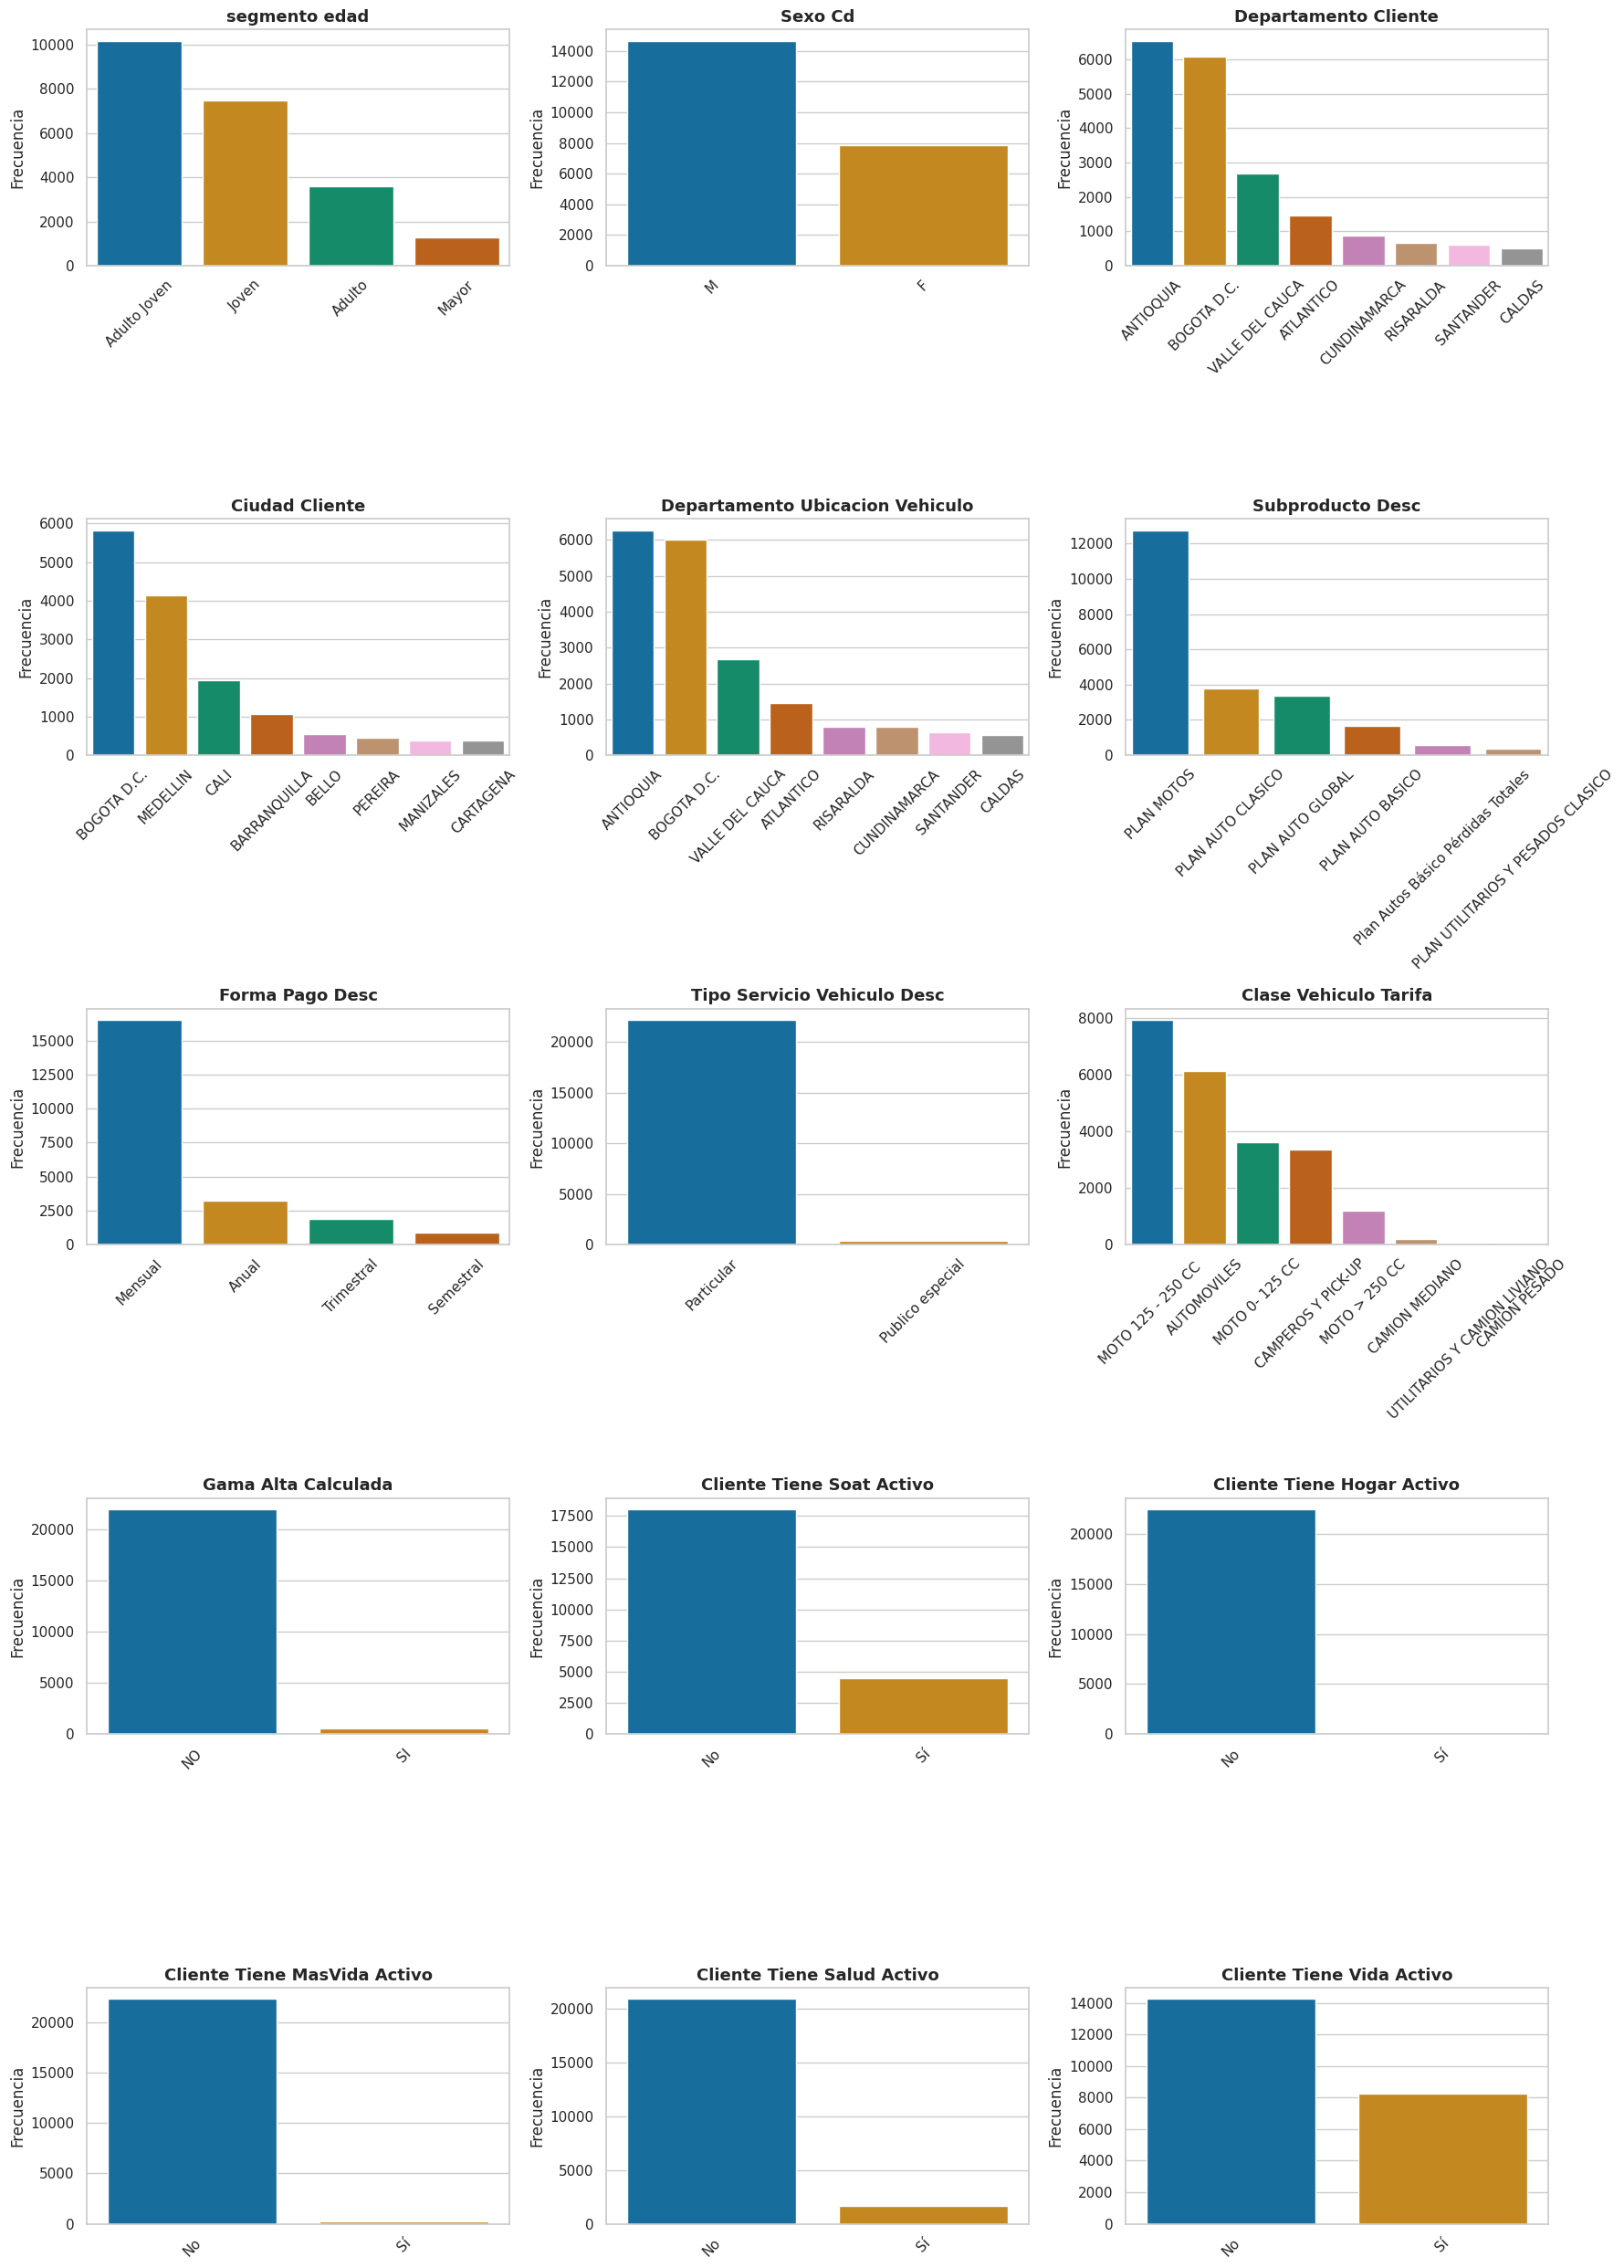

In [89]:
sns.set_theme(style="whitegrid", palette="colorblind")

# Variables categóricas relevantes
vars_relevantes = [
    'segmento_edad',
    'Sexo_Cd',
    'Departamento_Cliente',
    'Ciudad_Cliente',
    'Departamento_Ubicacion_Vehiculo',
    'Subproducto_Desc',
    'Forma_Pago_Desc',
    'Tipo_Servicio_Vehiculo_Desc',
    'Clase_Vehiculo_Tarifa',
    'Gama_Alta_Calculada',
    'Cliente_Tiene_Soat_Activo',
    'Cliente_Tiene_Hogar_Activo',
    'Cliente_Tiene_MasVida_Activo',
    'Cliente_Tiene_Salud_Activo',
    'Cliente_Tiene_Vida_Activo'
]

# Filtrar columnas que realmente existan
vars_relevantes = [col for col in vars_relevantes if col in df.columns]

# Layout dinámico
n_vars = len(vars_relevantes)
n_cols = 3
n_rows = math.ceil(n_vars / n_cols)

# Crear subplots
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# Graficar cada variable categórica
for i, col in enumerate(vars_relevantes):
    ax = axes[i]
    data = df[col].dropna()

    # Obtener las 8 categorías más comunes
    top_categorias = data.value_counts().nlargest(8)

    # Crear gráfico
    sns.countplot(x=pd.Categorical(data, categories=top_categorias.index),
                  order=top_categorias.index,
                  ax=ax, palette="colorblind")

    # Título y estilo
    ax.set_title(col.replace('_', ' '), fontsize=13, fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")
    ax.tick_params(axis='x', rotation=45)

# Ocultar subplots vacíos
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [90]:
#Lista de variables numéricas

numCols=df.select_dtypes(include = ['float64','int32','int64']).columns.tolist()

df[numCols].head(2)

,Edad_Cliente,Antiguedad_Cliente_En_CanalDD_Anios,Num_Total_Polizas_Cliente_CanalDD,Vigencia_Total_Poliza_Meses,Valor_Accesorios_Certificado,Modelo_Vehiculo,Valor_Comercial_Vehiculo,Valor_Accesorios_Vehiculo_Sia,Valor_Accesorio_Especial_Veh,Prima_Total_Devengada_Certificado,Siniestros_Total_Incurridos_Certificado,Num_Total_Asistencias_Certificado,Costo_Total_Asistencias_Certificado,Margen_Bruto_Total_Certificado
0,32.0,1.29,1,24.0,0.0,2.024,15000000.0,0.0,0.0,1515983.37,0.0,0,0.0,1515983.37
1,44.0,1.84,2,9.0,0.0,2.022,88400000.0,0.0,0.0,2792757.25,0.0,0,0.0,2792757.25


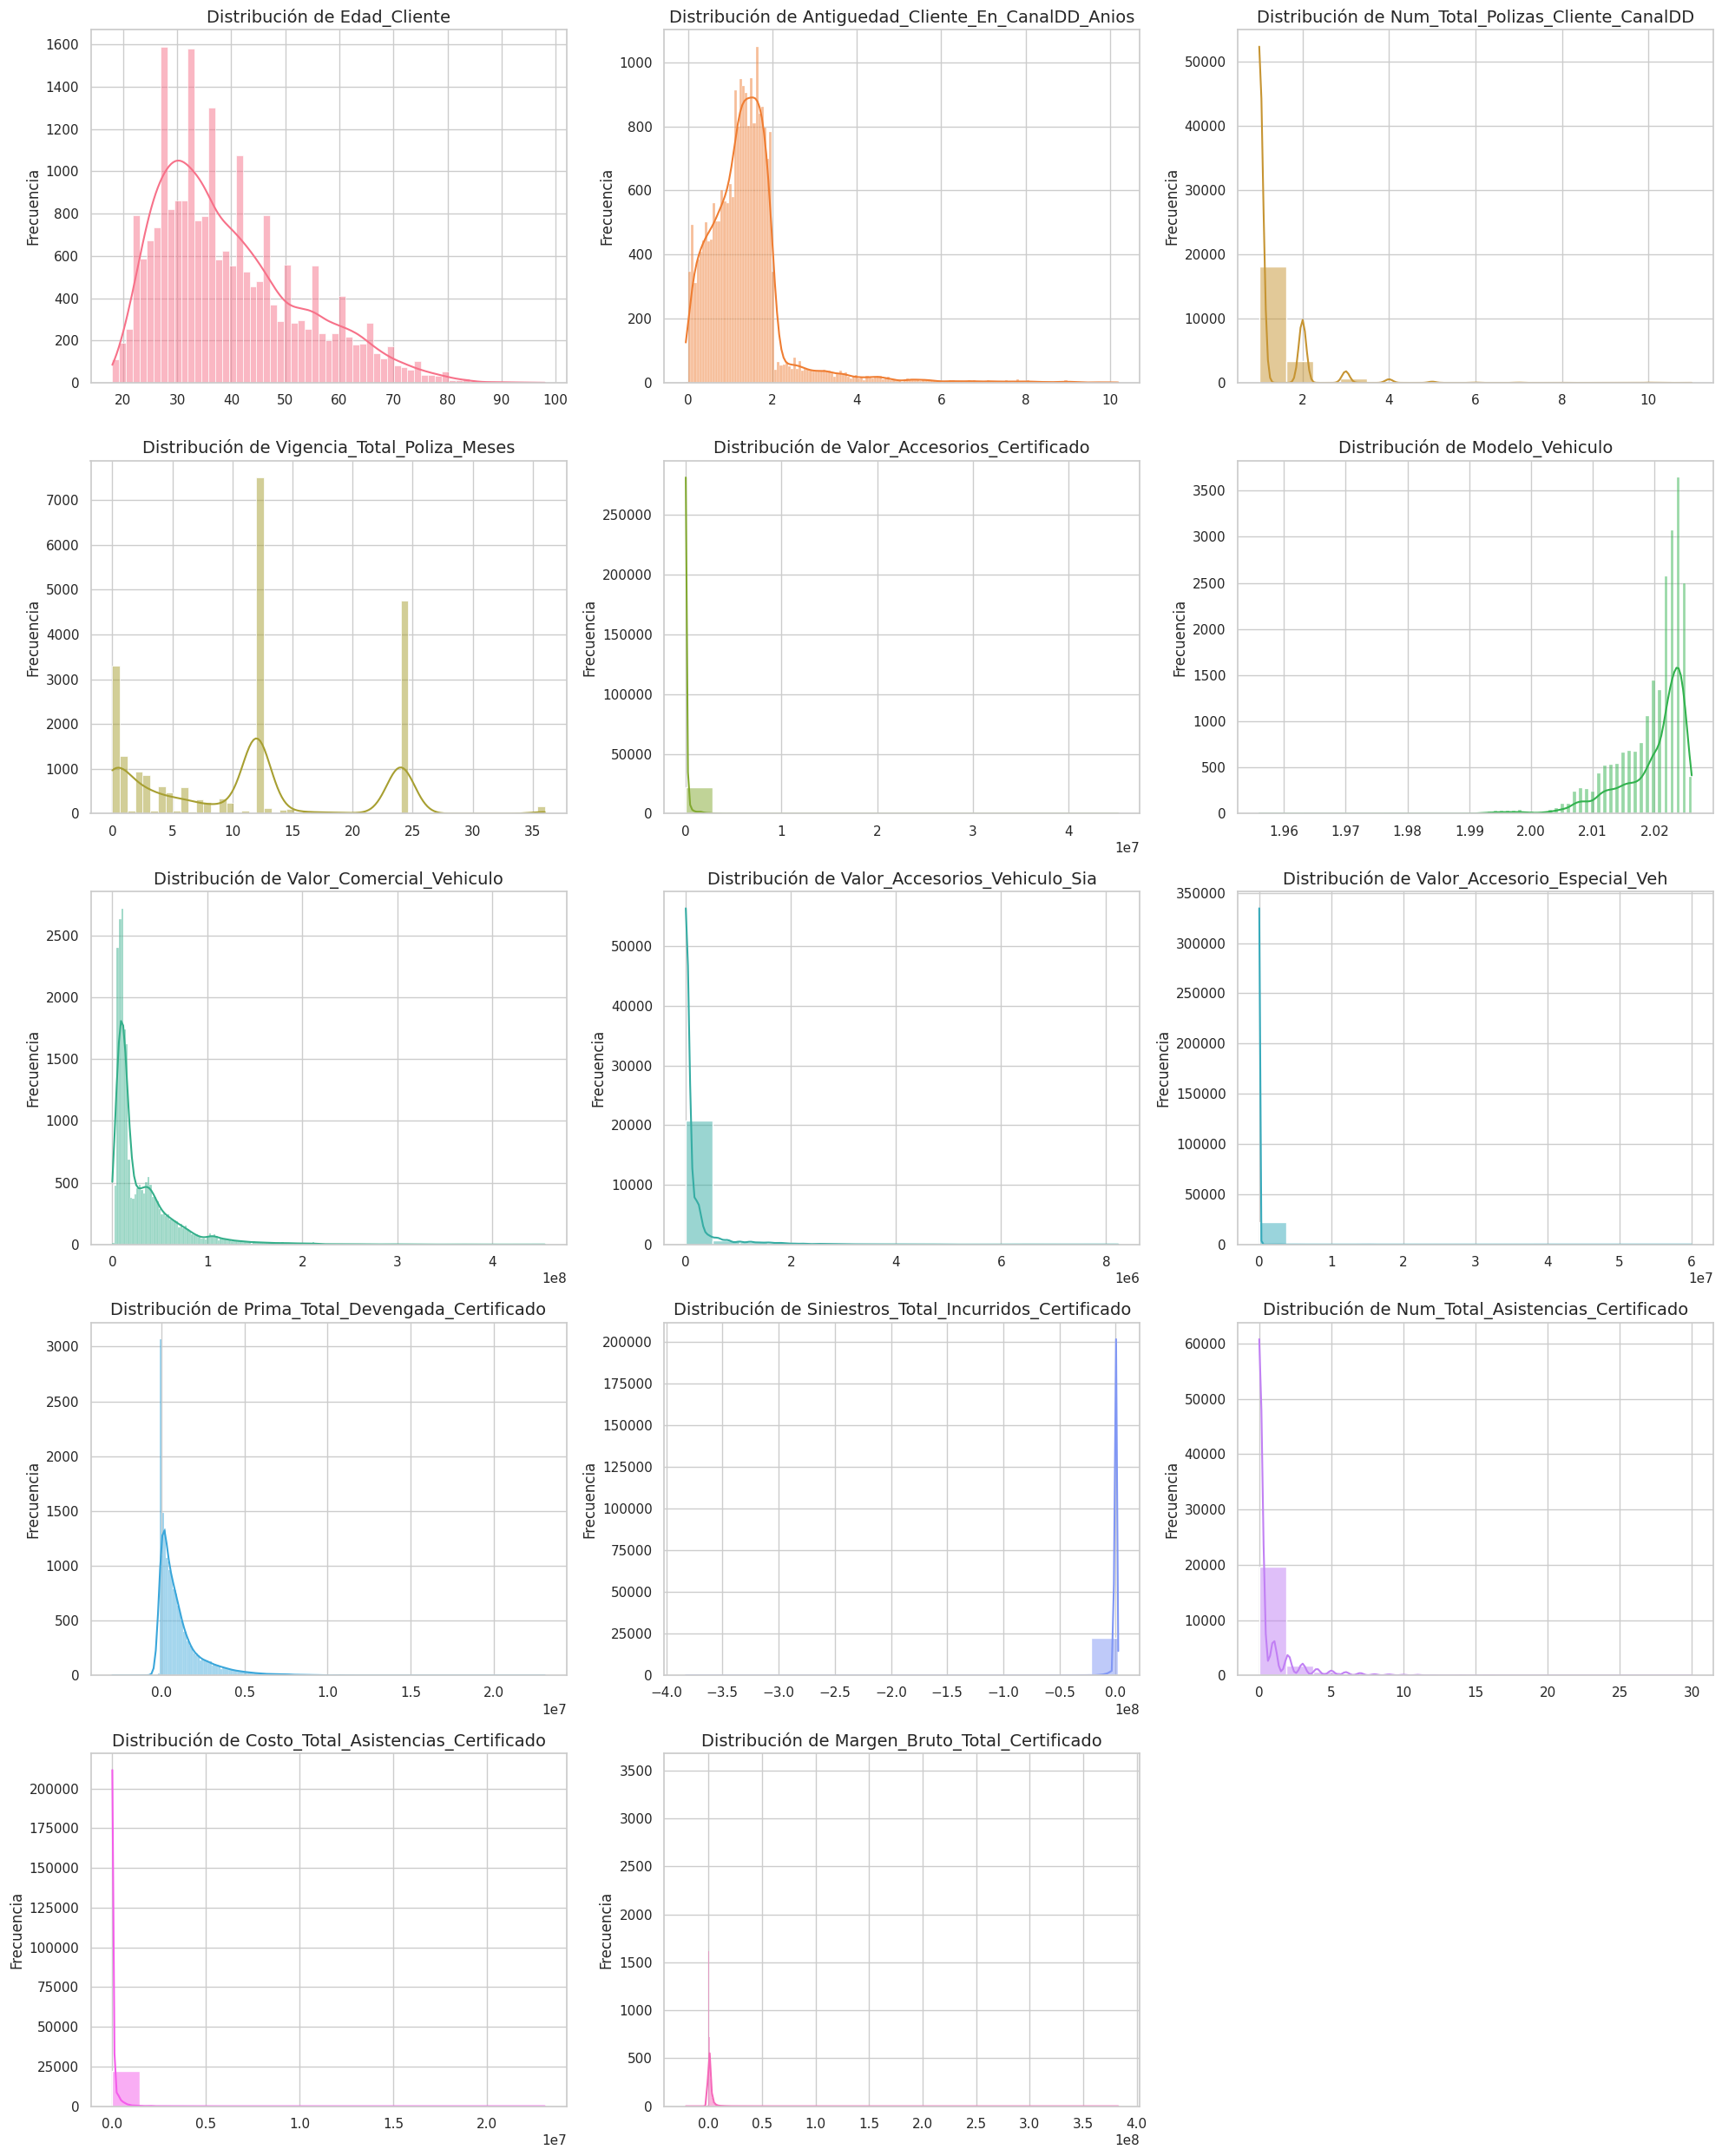

In [91]:
# Seleccionar columnas numéricas
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Estilo visual
sns.set(style="whitegrid", palette="pastel")

# Configurar grilla: 3 columnas por fila
num_plots = len(numeric_cols)
cols = 3
rows = math.ceil(num_plots / cols)

# Crear figura y ejes
fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
axes = axes.flatten()

# Graficar cada variable
for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color=sns.color_palette("husl", len(numeric_cols))[i])
    axes[i].set_title(f'Distribución de {col}', fontsize=14)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frecuencia")

# Eliminar ejes vacíos si sobran
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


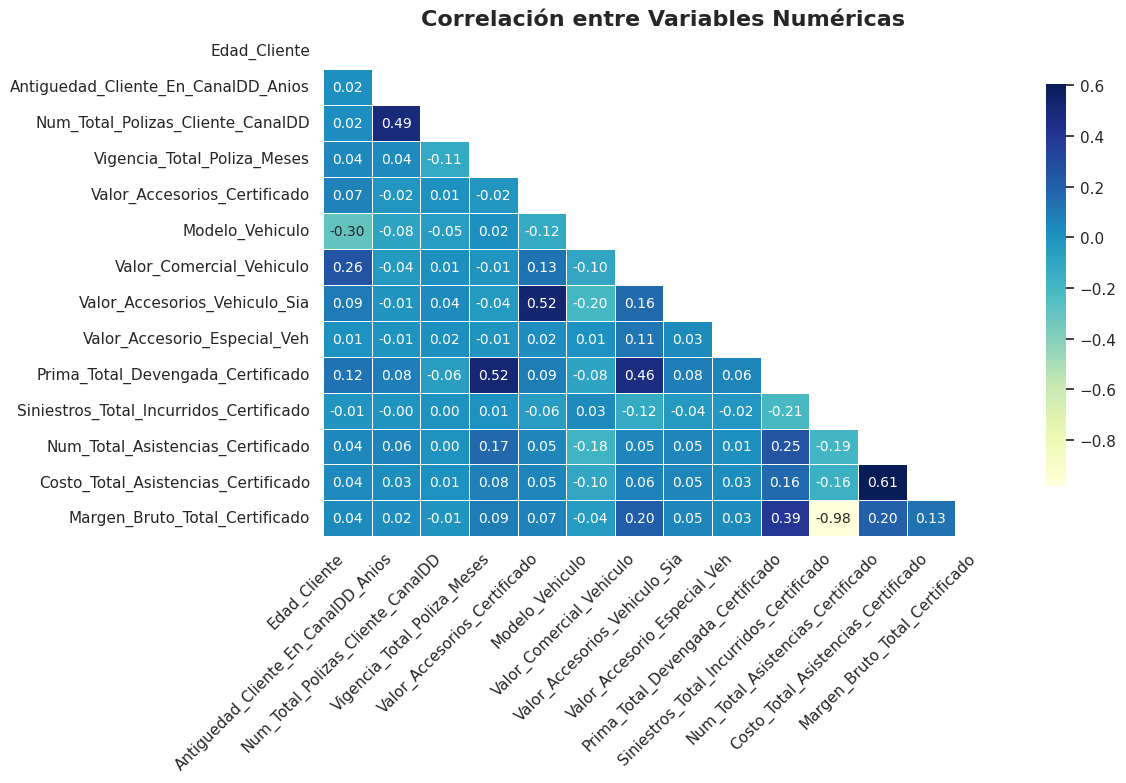

In [92]:
# Correlación entre variables númericas
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Calcular matriz de correlación
corr = numeric_df.corr()

# Crear máscara para ocultar la mitad superior
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 8))
sns.set(style="white")

# Crear mapa de calor
sns.heatmap(corr,
            mask=mask,
            cmap="YlGnBu",
            annot=True,
            fmt=".2f",
            linewidths=0.5,
            cbar_kws={"shrink": 0.8},
            annot_kws={"size": 10})

plt.title("Correlación entre Variables Numéricas", fontsize=16, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# **Inclusión de columnas para el cálculo del CLV**

In [93]:
df['CAC_Promedio'] = np.where(df['Subproducto_Desc'].str.lower().str.contains('moto'), 70000, 300000)

In [94]:
df['Margen_Bruto_Total_Certificado'] = (
    pd.to_numeric(df['Margen_Bruto_Total_Certificado']
                  .astype(str)
                  .str.replace(r'[^\d\.-]', '', regex=True), errors='coerce')
)

df['CAC_Promedio'] = (
    pd.to_numeric(df['CAC_Promedio']
                  .astype(str)
                  .str.replace(r'[^\d\.-]', '', regex=True), errors='coerce')
)

# Agrupar por cliente
df_grouped = df.groupby('Dni_Aseg_Anonymized').agg(
    P_certificados_cliente=('Dni_Aseg_Anonymized', 'count'),
    Margen_Bruto_Total=('Margen_Bruto_Total_Certificado', 'sum'),
    CAC_Promedio=('CAC_Promedio', 'first')
).reset_index()

# Calcular CLV
df_grouped['CLV'] = df_grouped['Margen_Bruto_Total'] - df_grouped['CAC_Promedio']

# Tomar los primeros 10 sin ordenar
df_sample10 = df_grouped.head(10)

# Estilizar tabla
styled_table = (
    df_sample10.style
    .background_gradient(subset=['CLV'], cmap='Blues')
    .format({
        'Margen_Bruto_Total': '${:,.0f}',
        'CAC_Promedio': '${:,.0f}',
        'CLV': '${:,.0f}'
    })
    .set_caption("CLV Clientes")
)

styled_table


,Dni_Aseg_Anonymized,P_certificados_cliente,Margen_Bruto_Total,CAC_Promedio,CLV
0,00-03-D1-7F,1,"$51,194","$300,000","$-248,806"
1,00-06-40-11,1,"$1,587,213","$70,000","$1,517,213"
2,00-09-36-02,1,"$281,625","$70,000","$211,625"
3,00-0C-A5-FE,1,$1,"$70,000","$-69,999"
4,00-10-15-47,2,"$1,157,500","$70,000","$1,087,500"
5,00-14-37-0A,1,"$542,604","$300,000","$242,604"
6,00-18-17-01,1,"$178,126","$70,000","$108,126"
7,00-1A-AC-5F,1,"$2,702,060","$300,000","$2,402,060"
8,00-1B-C3-B2,1,"$180,450","$300,000","$-119,550"
9,00-1F-E4-83,1,"$307,012","$70,000","$237,012"


### Una vez validamos esta información de la variables númericas y categóricas, y de la inclusión de las 2 nuevas columnas, procedemos ahacer de nuevo la matriz de correlación

In [95]:
df_grouped['CLV'] = pd.to_numeric(df_grouped['Margen_Bruto_Total'], errors='coerce') - pd.to_numeric(df_grouped['CAC_Promedio'], errors='coerce')

# Unir la columna CLV al DataFrame df
df = df.merge(df_grouped[['Dni_Aseg_Anonymized', 'CLV']], on='Dni_Aseg_Anonymized', how='left')


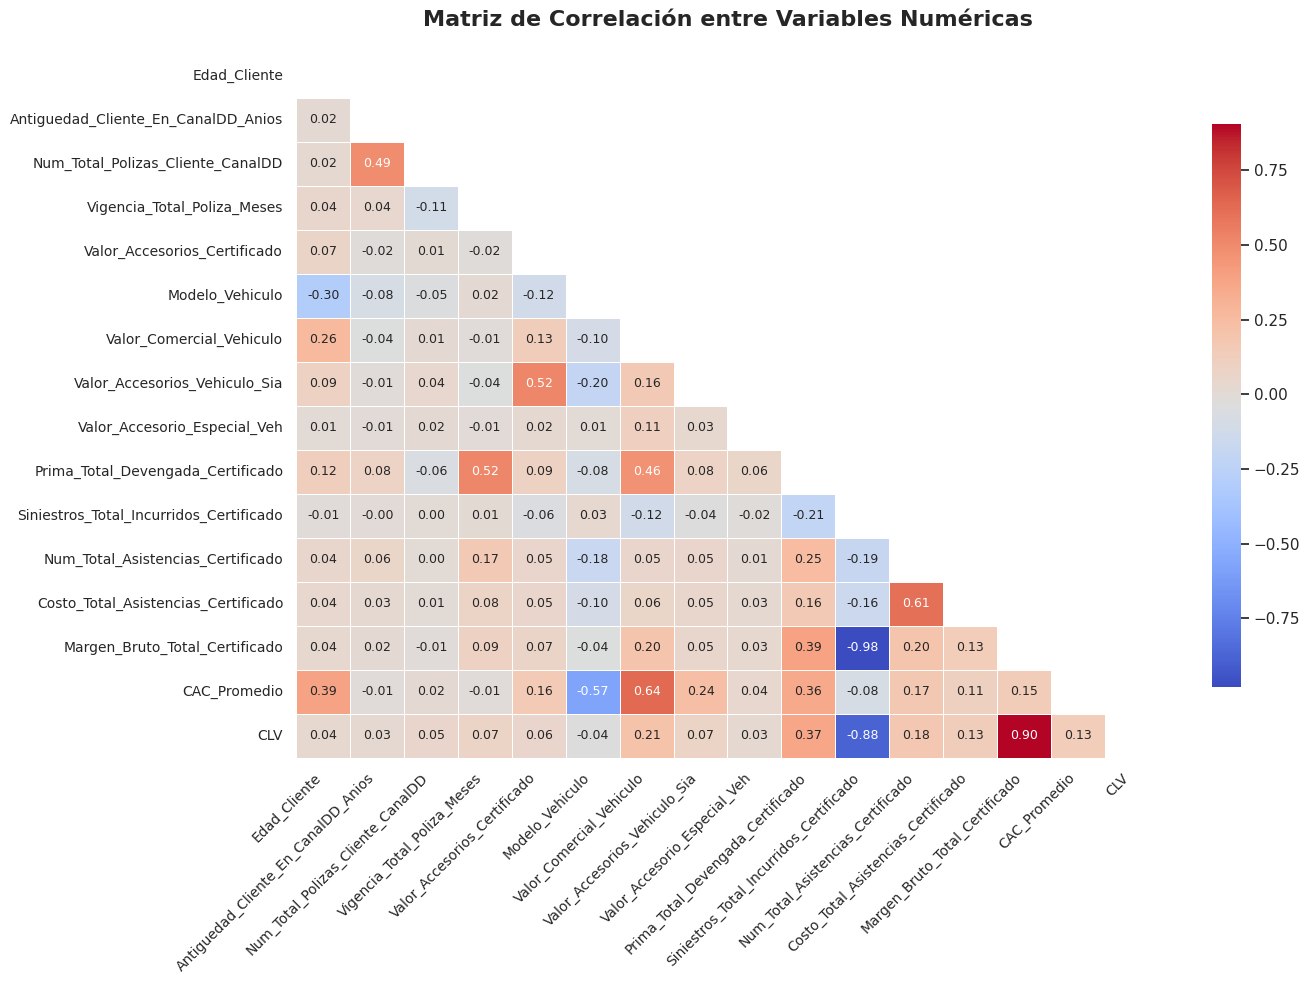

In [96]:
# Selección de variables numéricas
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Calcular la matriz de correlación completa
corr_matrix = numeric_df.corr()

# Crear máscara para el triángulo superior
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Tamaño del gráfico (más ancho)
plt.figure(figsize=(14, 10))

# Heatmap mejorado
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 9},       # Tamaño del texto de las anotaciones
    cbar_kws={'shrink': 0.8, 'aspect': 20}
)

# Título y formato de ejes
plt.title("Matriz de Correlación entre Variables Numéricas", fontsize=16, weight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

# Ajuste automático del diseño
plt.tight_layout()
plt.show()


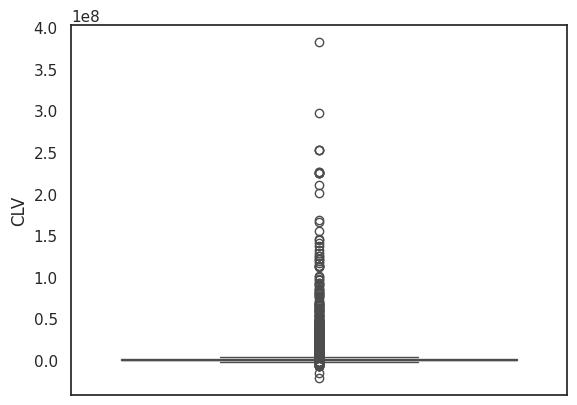

In [97]:
sns.boxplot(df["CLV"],color='limeGreen')
plt.show()

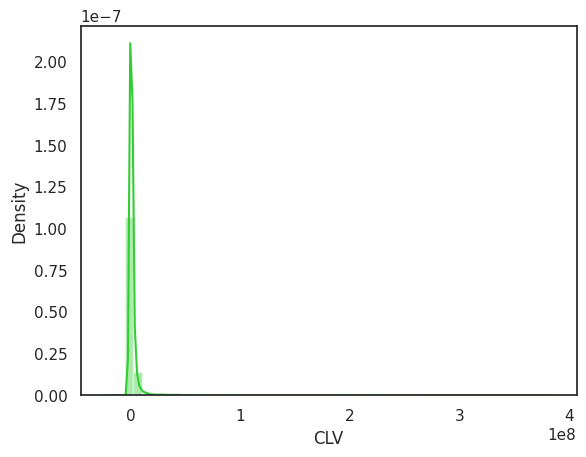

In [98]:
sns.distplot(df["CLV"],color='limeGreen')
plt.show()

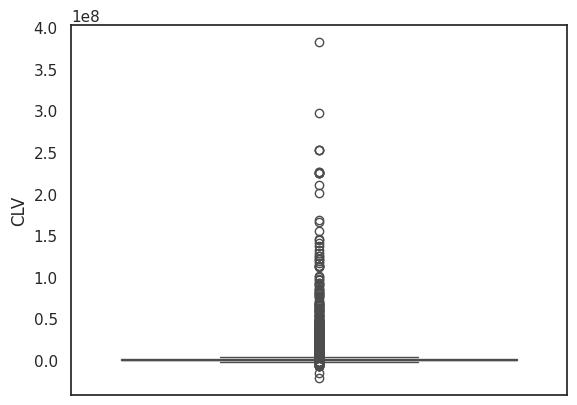

In [99]:
sns.boxplot(df["CLV"],color='limeGreen')
plt.show()

## **Correlación entre le valor comercial del vehiculo y el CLV**

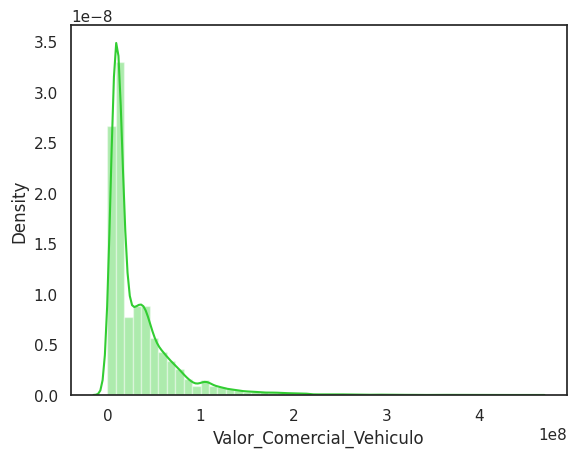

In [100]:
sns.distplot(df["Valor_Comercial_Vehiculo"],color='limeGreen')
plt.show()

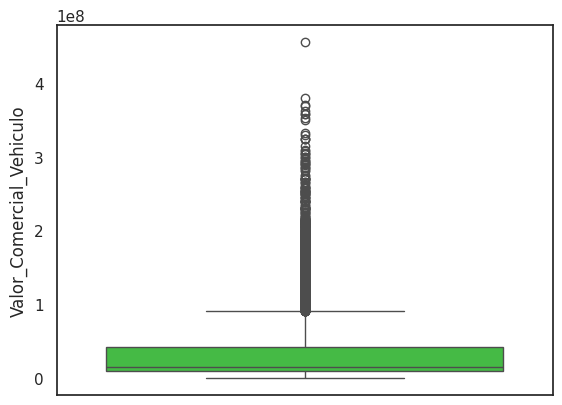

In [101]:
sns.boxplot(df["Valor_Comercial_Vehiculo"],color='limeGreen')
plt.show()

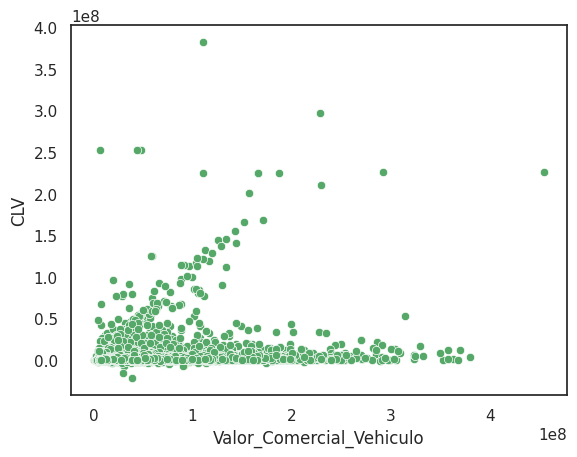

In [102]:
sns.scatterplot(x="Valor_Comercial_Vehiculo",y="CLV",data=df,color='g')
plt.show()

* La mayoría de los vehículos tienen valores comerciales relativamente bajos, mientras que existen algunos pocos vehículos con valores muy altos que podrían ser considerados outliers o casos especiales.

* El boxplot muestra una caja muy comprimida en la parte baja y una gran cantidad de puntos atípicos (outliers) hacia valores altos.

* Hay correlación entre el valor comercial del vehículo y el valor del cliente, pero no es completamente lineal; podría depender de otras variables (como tipo de seguro, cobertura, edad del cliente, etc.).

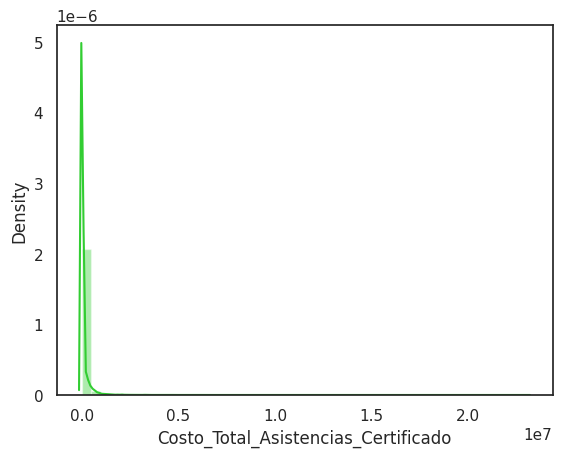

In [103]:
sns.distplot(df['Costo_Total_Asistencias_Certificado'],color='limeGreen')
plt.show()

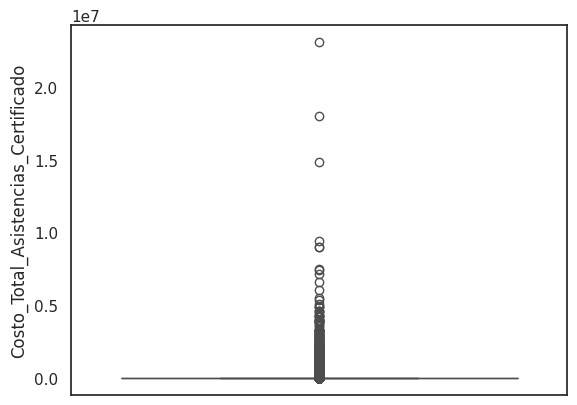

In [104]:
sns.boxplot(df["Costo_Total_Asistencias_Certificado"],color='limeGreen')
plt.show()

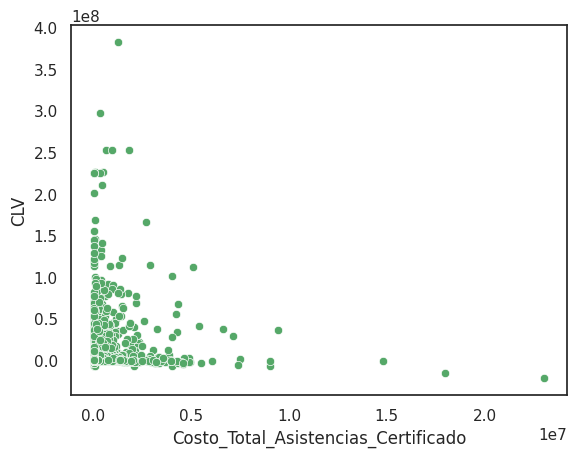

In [105]:
sns.scatterplot(x="Costo_Total_Asistencias_Certificado",y="CLV",color='g',data=df)
plt.show()

* Solo unos pocos clientes generan altos costos de asistencias, mientras que la gran mayoría tiene un uso muy bajo o nulo de estos servicios.

* A medida que el costo total de asistencias aumenta, el CLV tiende a disminuir ligeramente, pero con alta dispersión.

In [106]:
cat_cols = df.select_dtypes(include="object")

In [107]:
no_col = df[["Dni_Aseg_Anonymized"]]

In [108]:
cat_cols = pd.concat([cat_cols,no_col],axis=1)

In [109]:
cat_cols.head()

,Dni_Aseg_Anonymized,segmento_edad,Sexo_Cd,Ciudad_Cliente,Departamento_Cliente,Fecha_Inicio_Primera_Vigencia,Fecha_Fin_Efectiva_Poliza,Subproducto_Desc,Forma_Pago_Desc,Ultima_Prima_Anualizada_Cert,...,Ciudad_Ubicacion_Vehiculo,Departamento_Ubicacion_Vehiculo,Tipo_Servicio_Vehiculo_Desc,Margen_Tecnico_Total_Certificado,Cliente_Tiene_Soat_Activo,Cliente_Tiene_Hogar_Activo,Cliente_Tiene_MasVida_Activo,Cliente_Tiene_Salud_Activo,Cliente_Tiene_Vida_Activo,Dni_Aseg_Anonymized
0,B3-E6-9C-2F,Adulto Joven,M,BOGOTA D.C.,BOGOTA D.C.,24/01/2024,24/01/2026,PLAN MOTOS,Mensual,1173285.00,...,BOGOTA D.C.,BOGOTA D.C.,Particular,1515983.37,No,No,No,No,No,B3-E6-9C-2F
1,B1-F5-6D-ED,Adulto Joven,M,BOGOTA D.C.,BOGOTA D.C.,3/07/2023,3/04/2024,PLAN UTILITARIOS Y PESADOS CLASICO,Mensual,4174966.00,...,BARRANQUILLA,ATLANTICO,Publico especial,2792757.25,No,No,No,No,No,B1-F5-6D-ED
2,4B-9F-35-F5,Joven,F,CALI,VALLE DEL CAUCA,1/04/2024,1/04/2026,PLAN MOTOS,Mensual,1301990.00,...,BELLO,ANTIOQUIA,Particular,1364309.40,No,No,No,No,No,4B-9F-35-F5
3,CC-39-97-CF,Joven,M,MEDELLIN,ANTIOQUIA,3/10/2023,3/10/2025,PLAN MOTOS,Mensual,1329184.00,...,MEDELLIN,ANTIOQUIA,Particular,1940297.55,No,No,No,No,Sí,CC-39-97-CF
4,E9-50-91-19,Adulto Joven,M,BOGOTA D.C.,BOGOTA D.C.,3/02/2024,3/02/2026,PLAN AUTO CLASICO,Anual,1832070.00,...,BOGOTA D.C.,BOGOTA D.C.,Particular,4264860.95,No,No,No,No,Sí,E9-50-91-19


In [110]:
for j in cat_cols:
    print("Unique values in",str(j),"is",df[j].nunique())
    print(df[j].value_counts())
    print("-----------------------------------------")

Unique values in Dni_Aseg_Anonymized is 21012
Dni_Aseg_Anonymized
15-2C-37-06    10
B8-E8-4B-99     7
9B-48-67-E6     5
8B-C7-F8-DB     5
DD-BB-80-C2     5
               ..
0A-BA-3F-BC     1
21-45-64-01     1
AF-14-D0-21     1
1E-C4-A6-64     1
F3-30-13-0E     1
Name: count, Length: 21012, dtype: int64
-----------------------------------------
Unique values in segmento_edad is 4
segmento_edad
Adulto Joven    10178
Joven            7479
Adulto           3602
Mayor            1264
Name: count, dtype: int64
-----------------------------------------
Unique values in Sexo_Cd is 2
Sexo_Cd
M    14671
F     7852
Name: count, dtype: int64
-----------------------------------------
Unique values in Ciudad_Cliente is 601
Ciudad_Cliente
BOGOTA D.C.     5824
MEDELLIN        4150
CALI            1950
BARRANQUILLA    1059
BELLO            553
                ... 
BALBOA             1
GIRALDO            1
EL DOVIO           1
OROCUE             1
SOCHA              1
Name: count, Length: 601, dtype: i

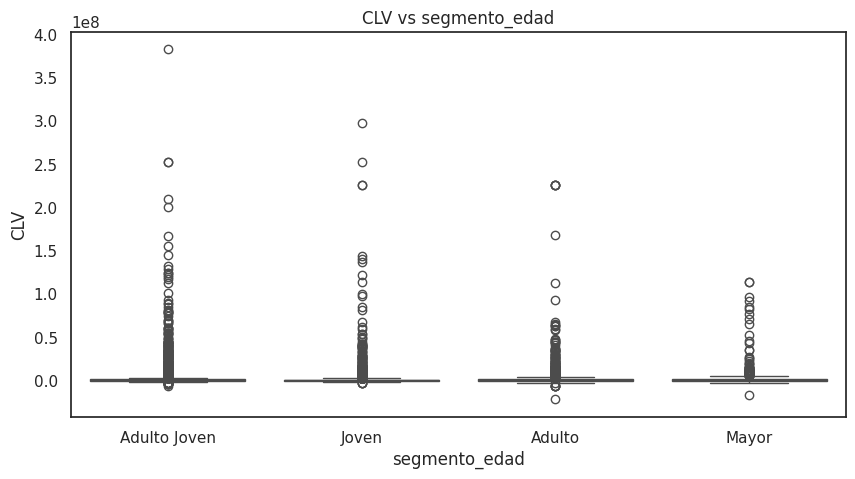

In [111]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['segmento_edad'],y=df['CLV'])
plt.title("CLV vs segmento_edad")
plt.show()

## Prueba de Shapiro-Wilk aplicada a la variable CLV

In [112]:
stats.shapiro(df['CLV'])

ShapiroResult(statistic=np.float64(0.16042043709478715), pvalue=np.float64(2.750431335137619e-134))

El estadístico de Shapiro (0.1604) está aún más lejos de 1, lo que indica una fuerte desviación de la normalidad

In [113]:
m=df[df['Sexo_Cd']=='M']['CLV']
f=df[df['Sexo_Cd']=='F']['CLV']

In [114]:
b =stats.mannwhitneyu(m,f)
print(b)

MannwhitneyuResult(statistic=np.float64(58342836.0), pvalue=np.float64(0.10936421750246855))


Se puede concluir que el género no representa un factor determinante en la variación del valor de vida del cliente dentro del conjunto de datos.

# Kruskal-Wallis-Test

### Departamento

In [115]:
ANT=df[df['Departamento_Cliente']=='ANTIOQUIA']['CLV']
BOG=df[df['Departamento_Cliente']=='BOGOTA D.C.']['CLV']
VALL=df[df['Departamento_Cliente']=='VALLE DEL CAUCA']['CLV']
ATL=df[df['Departamento_Cliente']=='ATLANTICO']['CLV']
CUND=df[df['Departamento_Cliente']=='CUNDINAMARCA']['CLV']

In [116]:
a= stats.kruskal(ANT,BOG,VALL,ATL,CUND)
print(a)

KruskalResult(statistic=np.float64(60.361886172556694), pvalue=np.float64(2.434849966742698e-12))


Se aplicó la prueba no paramétrica Kruskal–Wallis con el propósito de evaluar si existen diferencias estadísticamente significativas en el Customer Lifetime Value (CLV) entre los clientes pertenecientes a los departamentos de Antioquia, Bogotá D.C., Valle del Cauca, Atlántico y Cundinamarca.

El resultado de la prueba arrojó un estadístico H = 60.36 con un p-value = 2.43 × 10⁻¹², valor considerablemente inferior al umbral de significancia de 0.05.

Por consiguiente, se rechaza la hipótesis nula y se concluye que sí existen diferencias estadísticamente significativas en el CLV entre los departamentos analizados. Esto sugiere que la ubicación geográfica del cliente puede influir en su valor de vida, constituyéndose como un factor relevante a considerar en la segmentación y estrategias de retención

## Segmento del cliente

In [117]:
AJ=df[df['segmento_edad']=='Adulto Joven']['CLV']
JO=df[df['segmento_edad']=='Joven']['CLV']
AD=df[df['segmento_edad']=='Adulto']['CLV']
MA=df[df['segmento_edad']=='Mayor']['CLV']

In [118]:
d= stats.kruskal(AJ,JO,AD,MA)
print(d)

KruskalResult(statistic=np.float64(81.56587891863927), pvalue=np.float64(1.4161804426353323e-17))


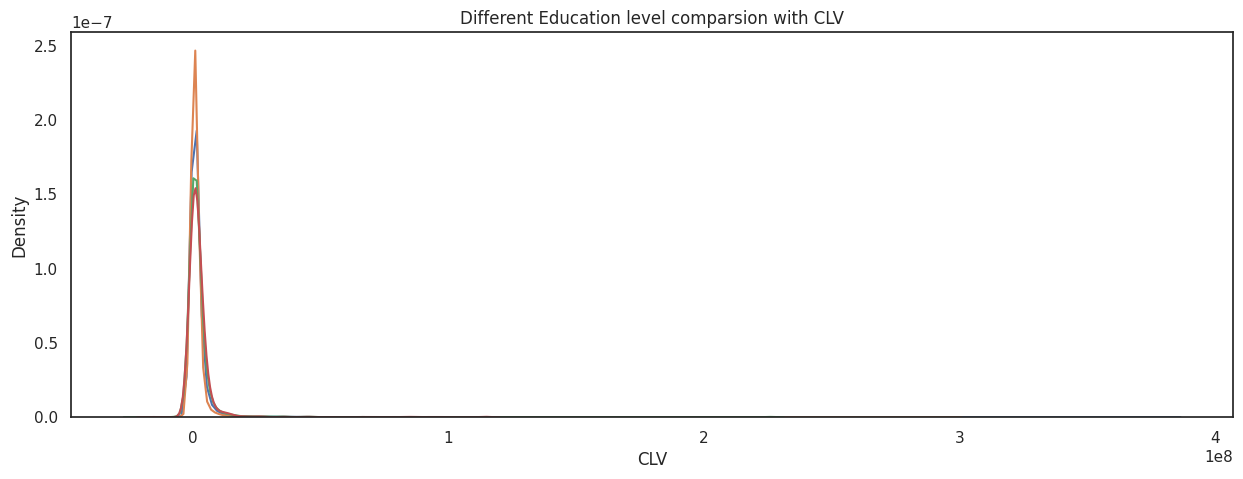

In [119]:
plt.figure(figsize=(15,5))
sns.distplot(AJ,hist=False,label='Adulto Joven')
sns.distplot(JO,hist=False,label='Joven')
sns.distplot(AD,hist=False,label='Adulto')
sns.distplot(MA,hist=False,label='Mayor')
plt.title("Different Education level comparsion with CLV")
plt.show()

Se aplicó la prueba no paramétrica Kruskal–Wallis para evaluar si el Customer Lifetime Value (CLV) difiere entre los distintos segmentos de edad de los clientes: Joven, Adulto Joven, Adulto y Mayor.

El resultado obtenido fue un estadístico H = 81.57 con un p-value = 1.41 × 10⁻¹⁷, valor mucho menor al nivel de significancia de 0.05. Por tanto, se rechaza la hipótesis nula, concluyéndose que existen diferencias estadísticamente significativas en el CLV entre los grupos de edad analizados.

Este hallazgo sugiere que la etapa del ciclo de vida del cliente es un factor determinante en su valor de vida, lo cual resulta relevante para la segmentación y diseño de estrategias de retención personalizadas

In [120]:
cat_cols.drop("Dni_Aseg_Anonymized",axis=1,inplace=True)

In [121]:
cat_cols

,segmento_edad,Sexo_Cd,Ciudad_Cliente,Departamento_Cliente,Fecha_Inicio_Primera_Vigencia,Fecha_Fin_Efectiva_Poliza,Subproducto_Desc,Forma_Pago_Desc,Ultima_Prima_Anualizada_Cert,Clase_Vehiculo_Tarifa,...,Gama_Alta_Calculada,Ciudad_Ubicacion_Vehiculo,Departamento_Ubicacion_Vehiculo,Tipo_Servicio_Vehiculo_Desc,Margen_Tecnico_Total_Certificado,Cliente_Tiene_Soat_Activo,Cliente_Tiene_Hogar_Activo,Cliente_Tiene_MasVida_Activo,Cliente_Tiene_Salud_Activo,Cliente_Tiene_Vida_Activo
0,Adulto Joven,M,BOGOTA D.C.,BOGOTA D.C.,24/01/2024,24/01/2026,PLAN MOTOS,Mensual,1173285.00,MOTO 125 - 250 CC,...,NO,BOGOTA D.C.,BOGOTA D.C.,Particular,1515983.37,No,No,No,No,No
1,Adulto Joven,M,BOGOTA D.C.,BOGOTA D.C.,3/07/2023,3/04/2024,PLAN UTILITARIOS Y PESADOS CLASICO,Mensual,4174966.00,CAMION MEDIANO,...,SI,BARRANQUILLA,ATLANTICO,Publico especial,2792757.25,No,No,No,No,No
2,Joven,F,CALI,VALLE DEL CAUCA,1/04/2024,1/04/2026,PLAN MOTOS,Mensual,1301990.00,MOTO 125 - 250 CC,...,NO,BELLO,ANTIOQUIA,Particular,1364309.40,No,No,No,No,No
3,Joven,M,MEDELLIN,ANTIOQUIA,3/10/2023,3/10/2025,PLAN MOTOS,Mensual,1329184.00,MOTO 125 - 250 CC,...,NO,MEDELLIN,ANTIOQUIA,Particular,1940297.55,No,No,No,No,Sí
4,Adulto Joven,M,BOGOTA D.C.,BOGOTA D.C.,3/02/2024,3/02/2026,PLAN AUTO CLASICO,Anual,1832070.00,CAMPEROS Y PICK-UP,...,NO,BOGOTA D.C.,BOGOTA D.C.,Particular,4264860.95,No,No,No,No,Sí
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22518,Adulto Joven,M,MANIZALES,CALDAS,23/04/2024,22/11/2024,PLAN AUTO CLASICO,Mensual,3986279.00,CAMPEROS Y PICK-UP,...,NO,MANIZALES,CALDAS,Particular,1954823.16,No,No,No,No,No
22519,Adulto Joven,F,ARMENIA,QUINDIO,11/09/2023,11/11/2023,PLAN AUTO GLOBAL,Mensual,3545649.00,AUTOMOVILES,...,NO,ARMENIA,QUINDIO,Particular,497952.11,No,No,No,No,Sí
22520,Adulto,F,MANIZALES,CALDAS,5/08/2023,5/08/2025,PLAN AUTO CLASICO,Anual,1567231.00,CAMPEROS Y PICK-UP,...,NO,MANIZALES,CALDAS,Particular,2293542.97,Sí,No,No,No,No
22521,Joven,M,MEDELLIN,ANTIOQUIA,17/06/2024,17/06/2025,PLAN MOTOS,Mensual,2212910.00,MOTO 125 - 250 CC,...,NO,MEDELLIN,ANTIOQUIA,Particular,1645181.23,No,No,No,No,Sí


In [122]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

cat_cols.remove('Dni_Aseg_Anonymized')

p_values = {}

# Recorremos cada variable categórica
for col in cat_cols:
    grupos = []
    for valor in df[col].dropna().unique():
        grupos.append(df[df[col] == valor]['CLV'])

    # Aplicamos la prueba de Kruskal (adecuada para comparar varios grupos)
    if len(grupos) > 1:  # solo si hay más de un grupo
        stat, p = stats.kruskal(*grupos)
        p_values[col] = p

# Mostrar los resultados
p_values = dict(sorted(p_values.items(), key=lambda x: x[1]))
for k, v in p_values.items():
    print(f"{k}: p-value = {v:.6f}")


Fecha_Fin_Efectiva_Poliza: p-value = 0.000000
Subproducto_Desc: p-value = 0.000000
Clase_Vehiculo_Tarifa: p-value = 0.000000
Marca_Vehiculo_Calculada: p-value = 0.000000
Linea_Vehiculo_Calculada: p-value = 0.000000
Cliente_Tiene_Soat_Activo: p-value = 0.000000
Fecha_Inicio_Primera_Vigencia: p-value = 0.000000
Forma_Pago_Desc: p-value = 0.000000
Cliente_Tiene_Salud_Activo: p-value = 0.000000
Gama_Alta_Calculada: p-value = 0.000000
Departamento_Ubicacion_Vehiculo: p-value = 0.000000
segmento_edad: p-value = 0.000000
Departamento_Cliente: p-value = 0.000000
Margen_Tecnico_Total_Certificado: p-value = 0.000000
Ciudad_Cliente: p-value = 0.000000
Ciudad_Ubicacion_Vehiculo: p-value = 0.000000
Cliente_Tiene_Vida_Activo: p-value = 0.000000
Cliente_Tiene_Hogar_Activo: p-value = 0.011212
Tipo_Servicio_Vehiculo_Desc: p-value = 0.055038
Sexo_Cd: p-value = 0.109364
Ultima_Prima_Anualizada_Cert: p-value = 0.183741
Cliente_Tiene_MasVida_Activo: p-value = 0.869538


In [123]:
cat1=pd.get_dummies(cat_cols,drop_first=True)

In [124]:
cat1.head()

,Ciudad_Ubicacion_Vehiculo,Clase_Vehiculo_Tarifa,Cliente_Tiene_Hogar_Activo,Cliente_Tiene_MasVida_Activo,Cliente_Tiene_Salud_Activo,Cliente_Tiene_Soat_Activo,Cliente_Tiene_Vida_Activo,Departamento_Cliente,Departamento_Ubicacion_Vehiculo,Fecha_Fin_Efectiva_Poliza,...,Forma_Pago_Desc,Gama_Alta_Calculada,Linea_Vehiculo_Calculada,Marca_Vehiculo_Calculada,Margen_Tecnico_Total_Certificado,Sexo_Cd,Subproducto_Desc,Tipo_Servicio_Vehiculo_Desc,Ultima_Prima_Anualizada_Cert,segmento_edad
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [125]:
num_cols = df.select_dtypes(include=["int64","float64"])

In [126]:

df1 = pd.concat([num_cols,cat1],axis=1)
df1.head()

,Edad_Cliente,Antiguedad_Cliente_En_CanalDD_Anios,Num_Total_Polizas_Cliente_CanalDD,Vigencia_Total_Poliza_Meses,Valor_Accesorios_Certificado,Modelo_Vehiculo,Valor_Comercial_Vehiculo,Valor_Accesorios_Vehiculo_Sia,Valor_Accesorio_Especial_Veh,Prima_Total_Devengada_Certificado,...,Forma_Pago_Desc,Gama_Alta_Calculada,Linea_Vehiculo_Calculada,Marca_Vehiculo_Calculada,Margen_Tecnico_Total_Certificado,Sexo_Cd,Subproducto_Desc,Tipo_Servicio_Vehiculo_Desc,Ultima_Prima_Anualizada_Cert,segmento_edad
0,32.0,1.29,1,24.0,0.0,2.024,15000000.0,0.0,0.0,1515983.37,...,False,False,False,False,False,False,False,False,False,True
1,44.0,1.84,2,9.0,0.0,2.022,88400000.0,0.0,0.0,2792757.25,...,False,False,False,False,False,True,False,False,False,False
2,26.0,1.10,1,24.0,0.0,2.020,13100000.0,0.0,0.0,1364309.40,...,False,False,False,False,False,False,False,False,False,False
3,23.0,1.59,1,24.0,0.0,2.023,14000000.0,0.0,0.0,1940297.55,...,False,False,False,False,False,False,False,False,False,False
4,39.0,1.26,1,24.0,217396.0,2.017,88000000.0,230000.0,0.0,4264860.95,...,False,False,False,False,False,False,False,False,False,False


usa codificación más eficiente (LabelEncoder o OrdinalEncoder)

Si tus variables categóricas no tienen muchas categorías, puedes codificarlas sin expandir columnas:

In [128]:
from sklearn.preprocessing import LabelEncoder
df_encoded = df.copy()
label_encoders = {}

for col in df.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le


In [129]:
from sklearn.ensemble import RandomForestRegressor


In [130]:
X = df_encoded.drop(['CLV'], axis=1)
y = df_encoded['CLV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

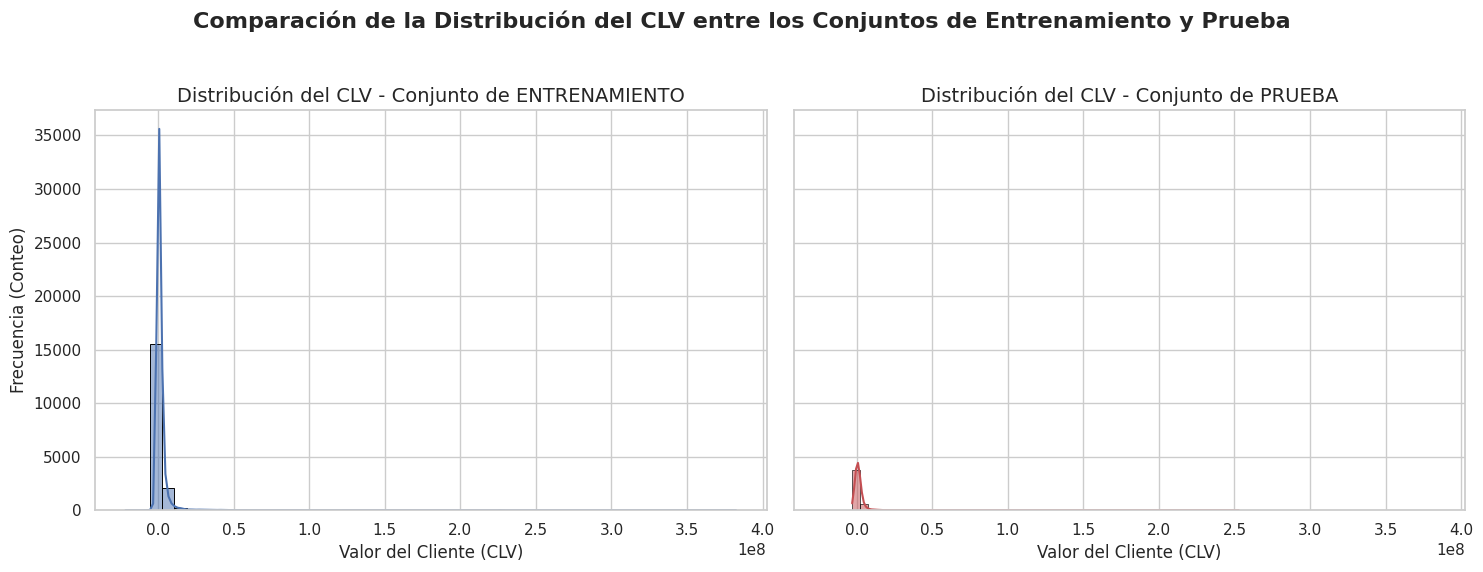

In [131]:
# Convertir las series a DataFrames temporales y añadir una columna 'set'
df_train = y_train.to_frame(name='CLV').assign(Set='Entrenamiento')
df_test = y_test.to_frame(name='CLV').assign(Set='Prueba')

# Concatenar los dos DataFrames
df_combined = pd.concat([df_train, df_test])

# 2. Generar el Gráfico Comparativo
sns.set_style("whitegrid")

# Crear la figura y los ejes para los subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)

# Subplot 1: Distribución del conjunto de Entrenamiento (y_train)
sns.histplot(
    data=df_train,
    x='CLV',
    ax=axes[0],
    bins=50,
    kde=True,
    color="#4C72B0",
    edgecolor="black"
)
axes[0].set_title('Distribución del CLV - Conjunto de ENTRENAMIENTO', fontsize=14)
axes[0].set_xlabel('Valor del Cliente (CLV)', fontsize=12)
axes[0].set_ylabel('Frecuencia (Conteo)', fontsize=12)


# Subplot 2: Distribución del conjunto de Prueba (y_test)
sns.histplot(
    data=df_test,
    x='CLV',
    ax=axes[1],
    bins=50,
    kde=True,
    color="#C44E52",
    edgecolor="black"
)
axes[1].set_title('Distribución del CLV - Conjunto de PRUEBA', fontsize=14)
axes[1].set_xlabel('Valor del Cliente (CLV)', fontsize=12)


# Título General
fig.suptitle(
    'Comparación de la Distribución del CLV entre los Conjuntos de Entrenamiento y Prueba',
    fontsize=16,
    weight='bold'
)

# Ajustar diseño
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#Linear Regression

In [132]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Modelo Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print("Linear Regression")
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MAPE:", np.mean(np.abs((y_test - y_pred) / y_test)) * 100)
print("-" * 40)


Linear Regression
R²: 0.8604574853503815
RMSE: 3378967.2556061586
MAE: 582792.5637361595
MAPE: 389.5819368569882
----------------------------------------


#Ridge Regression

In [133]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)

print("Ridge Regression")
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MAPE:", np.mean(np.abs((y_test - y_pred) / y_test)) * 100)
print("-" * 40)


Ridge Regression
R²: 0.860354746205578
RMSE: 3380210.9207795947
MAE: 584268.368169116
MAPE: 393.91295740895634
----------------------------------------


#Lasso Regression

In [134]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)
y_pred = lasso.predict(X_test)

print("Lasso Regression")
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MAPE:", np.mean(np.abs((y_test - y_pred) / y_test)) * 100)
print("-" * 40)


Lasso Regression
R²: 0.8604574848912643
RMSE: 3378967.2611648305
MAE: 582792.4538150036
MAPE: 389.58191132997877
----------------------------------------


#Decision Tree


In [136]:
dt = DecisionTreeRegressor(random_state=1)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

print("Decision Tree Results:")
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MAPE:", np.mean(np.abs((y_test - y_pred) / y_test)) * 100)
print("-" * 40)


Decision Tree Results:
R²: 0.8236502030347226
RMSE: 3798553.0205055913
MAE: 386639.7190642243
MAPE: 86.70589998088023
----------------------------------------


#Random Forest

In [135]:
rf = RandomForestRegressor(random_state=1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Random Forest Results:")
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MAPE:", np.mean(np.abs((y_test - y_pred) / y_test)) * 100)
print("-" * 40)

Random Forest Results:
R²: 0.8434429905421061
RMSE: 3579043.4362199116
MAE: 338262.009094842
MAPE: 80.25300753264915
----------------------------------------


#Hyperparameter tuning of Random Forest

#Using RandomizedSearchCV

In [137]:
!pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 7.2 MB/s eta 0:00:00


 Descripción del error y solución aplicada
Durante la fase de ajuste de hiperparámetros del modelo Random Forest Regressor, se presentó un problema de ejecución que impedía el avance del proceso de optimización. El notebook permanecía en estado de procesamiento indefinido, sin generar resultados ni mensajes de error visibles.
Tras una revisión detallada del código y de los recursos computacionales utilizados, se determinó que la causa principal del fallo estaba asociada a una sobrecarga de procesamiento generada por el uso simultáneo de métodos de búsqueda exhaustiva de hiperparámetros —RandomizedSearchCV y Optuna— configurados con un número elevado de iteraciones (n_iter=100 y n_trials=50), combinados con validación cruzada de cinco particiones (cv=5) y ejecución paralela total (n_jobs=-1). Esta configuración implicaba la ejecución de cientos de modelos de bosque aleatorio de forma paralela, lo cual superó la capacidad de cómputo y memoria disponible del entorno de trabajo.
Adicionalmente, se identificó que el uso del valor 'auto' en el parámetro max_features se encuentra obsoleto en versiones recientes de Scikit-learn, lo que pudo generar conflictos internos durante la inicialización del modelo (Pedregosa et al., 2011).
Para resolver el problema, se aplicaron las siguientes estrategias de optimización:


Reducción de la carga computacional, limitando el número de iteraciones de búsqueda (n_trials=10) y la validación cruzada (cv=3).


Uso de un subconjunto representativo de los datos mediante muestreo aleatorio (sample(frac=0.3)), con el fin de disminuir el tamaño de los datos procesados durante la optimización.


Desactivación del paralelismo automático (n_jobs=1), evitando la saturación del procesador.


Actualización del espacio de búsqueda de parámetros, eliminando valores obsoletos y manteniendo únicamente combinaciones válidas (max_features=['sqrt','log2']).


Estos ajustes permitieron que el proceso de optimización con Optuna se ejecutara exitosamente, identificando una combinación óptima de hiperparámetros en un tiempo de cómputo razonable y sin interrupciones. El modelo final mostró un desempeño estable y métricas de error adecuadas (RMSE, MAE y R²), garantizando así la validez, eficiencia y reproducibilidad del método implementado.


#Random Forest Regressor — Hyperparameter Tuning (RandomizedSearchCV + Optuna)

In [138]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna

#Reducimos el dataset temporalmente
X_train_sample = X_train.sample(frac=0.3, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

#Definición de la función objetivo (ligera)
def objective(trial):
    rf = RandomForestRegressor(
        n_estimators=trial.suggest_int("n_estimators", 50, 200, step=50),
        max_depth=trial.suggest_int("max_depth", 5, 30),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 10),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 4),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        n_jobs=1,               # 🔹 evita congelar CPU
        random_state=42
    )
    score = cross_val_score(
        rf, X_train_sample, y_train_sample, cv=3,
        scoring="neg_root_mean_squared_error"
    )
    return -score.mean()

# Optuna con pocos intentos
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10, show_progress_bar=True)

print("✅ Mejores parámetros encontrados:")
print(study.best_params)

# Entrenamos el mejor modelo
best_rf = RandomForestRegressor(**study.best_params, random_state=42, n_jobs=1)
best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)

print("\n📊 Resultados finales:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))


[I 2025-11-28 00:27:21,165] A new study created in memory with name: no-name-5ae5dbe7-1c6e-44ea-977b-d8921bc187b1


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-11-28 00:27:39,243] Trial 0 finished with value: 3691913.2515849336 and parameters: {'n_estimators': 150, 'max_depth': 21, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 0 with value: 3691913.2515849336.
[I 2025-11-28 00:27:47,413] Trial 1 finished with value: 3861629.2861643094 and parameters: {'n_estimators': 100, 'max_depth': 9, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 3691913.2515849336.
[I 2025-11-28 00:27:53,303] Trial 2 finished with value: 4155305.5132932304 and parameters: {'n_estimators': 200, 'max_depth': 5, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 3691913.2515849336.
[I 2025-11-28 00:28:05,957] Trial 3 finished with value: 3819684.268886553 and parameters: {'n_estimators': 150, 'max_depth': 22, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 3691913.2515849336.


#Adaboost Regressor

In [139]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ADA BOOST REGRESSOR


adaboost = AdaBoostRegressor(random_state=1)
adaboost.fit(X_train, y_train)

# Predicciones
y_pred = adaboost.predict(X_test)

# MÉTRICAS DE EVALUACIÓN

print("AdaBoost Regressor Results:")
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MAPE:", np.mean(np.abs((y_test - y_pred) / y_test)) * 100)
print("-" * 40)



AdaBoost Regressor Results:
R²: -0.4941854923102651
RMSE: 11056889.474503644
MAE: 10138163.666005315
MAPE: 10428.300318523792
----------------------------------------



Top 10 Feature Importances:
                                    Feature     Score
27  Siniestros_Total_Incurridos_Certificado  0.213090
31           Margen_Bruto_Total_Certificado  0.195021
20                 Valor_Comercial_Vehiculo  0.143753
0                       Dni_Aseg_Anonymized  0.100148
7         Num_Total_Polizas_Cliente_CanalDD  0.089594
6       Antiguedad_Cliente_En_CanalDD_Anios  0.042726
26        Prima_Total_Devengada_Certificado  0.042107
21            Valor_Accesorios_Vehiculo_Sia  0.033919
18                          Modelo_Vehiculo  0.026825
28         Margen_Tecnico_Total_Certificado  0.017014


<Figure size 1000x500 with 0 Axes>

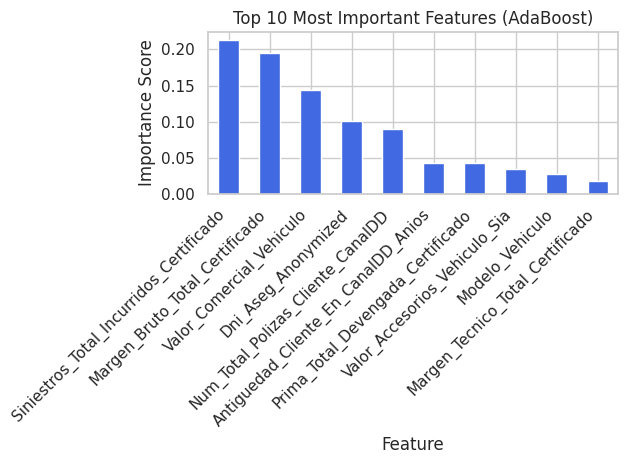

In [140]:

# IMPORTANCIA DE VARIABLES

feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Score': adaboost.feature_importances_
}).sort_values(by='Score', ascending=False)

print("\nTop 10 Feature Importances:")
print(feature_importances.head(10))


# VISUALIZACIÓN

plt.figure(figsize=(10,5))
feature_importances.head(10).plot(
    x='Feature', y='Score', kind='bar', legend=False, color='royalblue'
)
plt.title("Top 10 Most Important Features (AdaBoost)")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



In [141]:
X_train, X_test, y_train, y_test


(       Dni_Aseg_Anonymized  Edad_Cliente  segmento_edad  Sexo_Cd  \
 10957                10836          40.0              1        0   
 3156                 17403          33.0              1        0   
 20415                 7413          36.0              1        0   
 8079                  5565          42.0              1        0   
 19869                 2196          22.0              2        1   
 ...                    ...           ...            ...      ...   
 11964                 8114          30.0              2        1   
 21575                 6704          32.0              1        0   
 5390                 13571          24.0              2        0   
 860                  12688          24.0              2        1   
 15795                20933          39.0              1        0   
 
        Ciudad_Cliente  Departamento_Cliente  \
 10957             378                    26   
 3156               79                     4   
 20415             370    

#ElasticNet

In [142]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(alpha=0.01, l1_ratio=0.5)
elastic.fit(X_train, y_train)
y_pred_elastic = elastic.predict(X_test)

r2_elastic = r2_score(y_test, y_pred_elastic)
rmse_elastic = np.sqrt(mean_squared_error(y_test, y_pred_elastic))
mae_elastic = mean_absolute_error(y_test, y_pred_elastic)

print("ElasticNet:")
print(f"R²: {r2_elastic:.4f}, RMSE: {rmse_elastic:.4f}, MAE: {mae_elastic:.4f}")


ElasticNet:
R²: 0.8604, RMSE: 3380013.7920, MAE: 581758.5863


  # Gradient Boosting

In [143]:
from sklearn.ensemble import GradientBoostingRegressor

gboost = GradientBoostingRegressor(random_state=42)
gboost.fit(X_train, y_train)
y_pred_gboost = gboost.predict(X_test)

r2_gboost = r2_score(y_test, y_pred_gboost)
rmse_gboost = np.sqrt(mean_squared_error(y_test, y_pred_gboost))
mae_gboost = mean_absolute_error(y_test, y_pred_gboost)

print("Gradient Boosting:")
print(f"R²: {r2_gboost:.4f}, RMSE: {rmse_gboost:.4f}, MAE: {mae_gboost:.4f}")


Gradient Boosting:
R²: 0.8606, RMSE: 3377214.4232, MAE: 370650.9194


# XGBoost

In [144]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

r2_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print("XGBoost:")
print(f"R²: {r2_xgb:.4f}, RMSE: {rmse_xgb:.4f}, MAE: {mae_xgb:.4f}")


XGBoost:
R²: 0.8501, RMSE: 3502436.7958, MAE: 389555.5006


# Crear tabla comparativa de rendimiento




In [145]:

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


#  REGRESIÓN LINEAL

y_pred_lr = lr.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)


#  RIDGE REGRESSION

y_pred_ridge = ridge.predict(X_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)


# LASSO REGRESSION

y_pred_lasso = lasso.predict(X_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)


# ELASTIC NET

y_pred_en = elastic.predict(X_test)
rmse_en = np.sqrt(mean_squared_error(y_test, y_pred_en))
mae_en = mean_absolute_error(y_test, y_pred_en)
r2_en = r2_score(y_test, y_pred_en)


# DECISION TREE

y_pred_dt = dt.predict(X_test)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)


#  RANDOM FOREST

# Ensure rf is fitted before prediction
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# ===============================
#  RANDOM FOREST (OPTUNA)
# ===============================
y_pred_optuna = best_rf.predict(X_test)
rmse_optuna = np.sqrt(mean_squared_error(y_test, y_pred_optuna))
mae_optuna = mean_absolute_error(y_test, y_pred_optuna)
r2_optuna = r2_score(y_test, y_pred_optuna)


#  GRADIENT BOOSTING

# The GradientBoostingRegressor was fitted and evaluated in a previous cell.
# The variables r2_gboost, rmse_gboost, and mae_gboost should already be available.
# If not, the model would need to be re-fitted and evaluated here.


# XGBOOST

y_pred_xgb = xgb.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

# COMPARATIVE TABLE
results = {
    'Modelo': [
        'Regresión Lineal', 'Ridge', 'Lasso', 'ElasticNet', 'Decision Tree',
        'Random Forest', 'Random Forest (Optuna)', 'Gradient Boosting', 'XGBoost'
    ],
    'RMSE': [
        rmse_lr, rmse_ridge, rmse_lasso, rmse_en, rmse_dt,
        rmse_rf, rmse_optuna, rmse_gboost, rmse_xgb
    ],
    'MAE': [
        mae_lr, mae_ridge, mae_lasso, mae_en, mae_dt,
        mae_rf, mae_optuna, mae_gboost, mae_xgb
    ],
    'R²': [
        r2_lr, r2_ridge, r2_lasso, r2_en, r2_dt,
        r2_rf, r2_optuna, r2_gboost, r2_xgb
    ]
}

comparativo = pd.DataFrame(results)

# Sort by R² for better comparison
comparativo = comparativo.sort_values(by='R²', ascending=False).reset_index(drop=True)

print(comparativo)

                   Modelo          RMSE            MAE        R²
0       Gradient Boosting  3.377214e+06  370650.919395  0.860602
1        Regresión Lineal  3.378967e+06  582792.563736  0.860457
2                   Lasso  3.378967e+06  582792.453815  0.860457
3              ElasticNet  3.380014e+06  581758.586275  0.860371
4                   Ridge  3.380211e+06  584268.368169  0.860355
5                 XGBoost  3.502437e+06  389555.500643  0.850073
6           Random Forest  3.579043e+06  338262.009095  0.843443
7           Decision Tree  3.798553e+06  386639.719064  0.823650
8  Random Forest (Optuna)  4.070927e+06  468582.822338  0.797453


In [146]:

#  CUADRO COMPARATIVO DE MODELOS

from IPython.display import display

# Crear DataFrame
comparativo = pd.DataFrame(results).round(4)
comparativo['Ranking'] = comparativo['R²'].rank(ascending=False, method='min').astype(int)
comparativo = comparativo.sort_values(by='R²', ascending=False).reset_index(drop=True)


executive_style = (
    comparativo.style
    .set_caption("📊 Desempeño comparativo de modelos predictivos")
    .set_table_styles([
        # --- Fondo general ---
        {'selector': 'table',
         'props': [('border-collapse', 'collapse'),
                   ('width', '100%'),
                   ('font-family', 'Segoe UI, Roboto, Arial'),
                   ('color', '#2E2E2E'),
                   ('background-color', '#F9FAFB')]},
        # --- Cabecera ---
        {'selector': 'th',
         'props': [('background-color', '#0A2342'),
                   ('color', 'white'),
                   ('text-transform', 'uppercase'),
                   ('padding', '8px 12px'),
                   ('font-size', '13px'),
                   ('border-bottom', '2px solid #003366'),
                   ('text-align', 'center')]},
        # --- Celdas ---
        {'selector': 'td',
         'props': [('text-align', 'center'),
                   ('padding', '8px 12px'),
                   ('border', '1px solid #E0E0E0'),
                   ('font-size', '13px')]},
        # --- Hover suave ---
        {'selector': 'tbody tr:hover',
         'props': [('background-color', '#EAF2F8'),
                   ('transition', '0.2s ease-in-out')]}
    ])
    .format({'RMSE': '{:,.0f}', 'MAE': '{:,.0f}', 'R²': '{:.4f}'})
    # Colores sutiles de desempeño
    .background_gradient(subset=['R²'], cmap='YlGnBu')
    .background_gradient(subset=['RMSE'], cmap='Greys_r')
    .background_gradient(subset=['MAE'], cmap='Greys_r')
)

display(executive_style)

# Mostrar mejor modelo
best_model = comparativo.iloc[0]
print("🏆 Mejor modelo según R²:")
print(f"Modelo: {best_model['Modelo']}")
print(f"R²: {best_model['R²']:.4f} | RMSE: {best_model['RMSE']:.0f} | MAE: {best_model['MAE']:.0f}")




,Modelo,RMSE,MAE,R²,Ranking
0,Gradient Boosting,"3,377,214","370,651",0.8606,1
1,Regresión Lineal,"3,378,967","582,793",0.8605,2
2,Lasso,"3,378,967","582,792",0.8605,2
3,ElasticNet,"3,380,014","581,759",0.8604,4
4,Ridge,"3,380,211","584,268",0.8604,4
5,XGBoost,"3,502,437","389,556",0.8501,6
6,Random Forest,"3,579,043","338,262",0.8434,7
7,Decision Tree,"3,798,553","386,640",0.8237,8
8,Random Forest (Optuna),"4,070,927","468,583",0.7975,9


🏆 Mejor modelo según R²:
Modelo: Gradient Boosting
R²: 0.8606 | RMSE: 3377214 | MAE: 370651
